In [123]:
import warnings
warnings.filterwarnings('ignore')

import pprint  # Pretty print data structures
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import sklearn
import joblib
import skactiveml
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty, ElementFraction
from matminer.featurizers.base import MultipleFeaturizer
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
plt.style.use('ggplot')  # Set Matplotlib style to 'ggplot'

# Config
CSV_PATH = '../data/bg_id/bg_id.csv'
TARGET_COL = 'bg_pbesol (eV)'

BLACKLIST_COLS = ['bg_hse06 (eV)','bg_pbesol (eV)','formula','material','composition']
Magpie_features = ElementProperty.from_preset('magpie').feature_labels()
innate_features = [
    'material',
    'formula',
    'bg_hse06 (eV)',
    'bg_pbesol (eV)',
    'r_s (AA)',
    'r_val (AA)',
    'e_H (eV)',
    'e_L (eV)',
    'AN',
    'IP (eV)',
    'EA (eV)',
    'r_cov (AA)',
    'EN (Pauling)',
    'N_val',
    'N_unf',
    'CE (eV/atom)',
]
features_full = innate_features + Magpie_features
features = [c for c in features_full if c not in BLACKLIST_COLS]

def build_X(df, scaler=StandardScaler(), train=False, raw=False):
    '''
    Build X with scaled continuous part and fingerprints.

    Args:
        df: dataframe with a 'smiles' column and qm9_features columns
        scaler: fitted scaler, or None to create a StandardScaler
        train: if True, fit scaler on continuous features
        raw: if True, return unscaled X
        n_jobs: number of CPU cores to use for fingerprinting

    Returns:
        X: feature matrix
    '''
    df = df.copy()
    X = df[features].to_numpy()

    if raw:
        return X

    X = (
        scaler.fit_transform(X) if train
        else scaler.transform(X)
    )

    return X

def plot_prediction(X, y, model, model_name=None, name=TARGET_COL, figsize=(6, 6), save=None, format='pdf'):
    '''
    Plot predictions for the given model and data.

    Args:
        X : Input features (np.array).
        y : True target values (np.array).
        model: Fitted model.
        model_name: Name of the model (str).
        name: Name of the target value (str).
        figsize: Figure size (tuple).
        save: Save path (str).
        format: Save format (str).
    '''
    y_pred = model.predict(X)
    errors = np.abs(y_pred-y)/y
    norm = colors.Normalize(vmin=0.0, vmax=1.0, clip=True)
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y, y_pred, c=errors, cmap='viridis', norm=norm, label='predicted values')
    ax.plot(y, y, 'r-', label='ideal')
    ax.set_xlabel(f'true {name}', fontsize=14)
    ax.set_ylabel(f'predicted {name}', fontsize=14)
    ax.legend(facecolor='white', fontsize=14)
    if model_name is None:
        ax.set_title(f'{model.__class__.__name__} prediction plot\n{name}', fontsize=16)
    else:
        ax.set_title(f'{model_name} prediction plot\n{name}', fontsize=16)
    
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()
    print('Training scores:')
    print(f'MAE = {mean_absolute_error(y,y_pred):.4f}')
    print(f'MSE = {mean_squared_error(y,y_pred):.4f}')
    print(f'RMSE = {root_mean_squared_error(y,y_pred):.4f}')
    print(f'r^2 = {r2_score(y,y_pred):.4f}')

def df_groupby(df):
    '''
    Regroups the AL history df into a new df for plotting.

    Args:
        df : AL history df (pd.DataFrame)
    '''
    df = df.groupby('n_labeled').agg(
        mae_test=('mae_test', 'mean'),   min_mae_test=('mae_test', 'min'),   max_mae_test=('mae_test', 'max'),
        mse_test=('mse_test', 'mean'),   min_mse_test=('mse_test', 'min'),   max_mse_test=('mse_test', 'max'),
        rmse_test=('rmse_test', 'mean'), min_rmse_test=('rmse_test', 'min'), max_rmse_test=('rmse_test', 'max'),
        r2_test=('r2_test', 'mean'),     min_r2_test=('r2_test', 'min'),     max_r2_test=('r2_test', 'max'),
        mae_val=('mae_val', 'mean'),   min_mae_val=('mae_val', 'min'),   max_mae_val=('mae_val', 'max'),
        mse_val=('mse_val', 'mean'),   min_mse_val=('mse_val', 'min'),   max_mse_val=('mse_val', 'max'),
        rmse_val=('rmse_val', 'mean'), min_rmse_val=('rmse_val', 'min'), max_rmse_val=('rmse_val', 'max'),
        r2_val=('r2_val', 'mean'),     min_r2_val=('r2_val', 'min'),     max_r2_val=('r2_val', 'max'),
    ).reset_index()
    return df

def plot_al(dfs, labels, score, save=None, format='pdf'):
    '''
    Plot AL metrics base on labeled samples.

    Args:
        dfs : List of Data Frames modified with df_groupby (list).
        labels : List of AL strategies (list).
        score : Dictionary of metric scores of baseline model (dict).
        save : Save path (str).
        format : Save format (str).
    '''
    metrics = [
        ('mae_test', 'MAE (Eh)'),
        ('rmse_test', 'RMSE (Eh)'),
        ('r2_test', 'R²'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Generate a color palette dynamically based on the number of dataframes
    cmap = plt.get_cmap('tab10')
    colors = [cmap(i) for i in range(len(dfs))]

    for ax, (key, label) in zip(axes, metrics):
        # Loop through dataframes, labels, and the auto-generated colors
        for df, name, color in zip(dfs, labels, colors):
            ax.plot(
                df['n_labeled'],
                df[key],
                marker='o',
                color=color,
                label=name,
                linewidth=3,
            )
            # ax.fill_between(
            #     df['n_labeled'],
            #     df[f'min_{key}'],
            #     df[f'max_{key}'],
            #     alpha=0.2,
            #     color=color,
            # )

        # Plot the baseline reference line
        baseline_val = score[key]
        ax.axhline(
            baseline_val,
            color='black',
            ls='--',
            label=f'full = {baseline_val:.4f}',
            linewidth=2,
        )

        
        ax.set_title(label, fontsize=16)
        ax.set_xlabel("Labeled samples", fontsize=16)
        ax.set_ylabel(label, fontsize=16)
        ax.legend(facecolor='white', fontsize=14)
        ax.tick_params(axis="both", labelsize=14)

    plt.tight_layout()
    if save is not None:
        fig.savefig(save, format=format, dpi=300)
    plt.show()
    
def print_cross_val(X, y, model, splits=5, random_state=42):
    '''
    Print cross validation scores for the given model and data.

    Args:
        X : Input features (np.array).
        y : True target values (np.array).
        model: Fitted model.
        n_splits: Number of CV splits (int).
        random_state: Random state seed (int).
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])

    cv = KFold(n_splits=splits, shuffle=True, random_state=random_state)
    scoring_metrics = {
        'mae':  'neg_mean_absolute_error',
        'mse':  'neg_mean_sqared_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2':   'r2',
    }
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring_metrics)

    print('Cross-validation scores:')
    print(f'Mean MAE  = {np.mean(np.abs(results['test_mae'])):.4f}')
    print(f'Mean MSE  = {np.mean(np.abs(results['test_mse'])):.4f}')
    print(f'Mean RMSE = {np.mean(np.abs(results['test_rmse'])):.4f}')
    print(f'Mean R²   = {np.mean(results['test_r2']):.4f}')

def plot_violin(X, y, models, metric='rmse', target_name=TARGET_COL, splits=5, y_min=0, y_max=None, figsize=(10, 6)):
    '''
    Plot RMSE violin plot for given models and data.

    Args:
        X           : Input features (np.array).
        y           : True target values (np.array).
        models      : List of unfitted model instances (list).
        target_name : Label for plot title (str).
        splits      : Number of CV splits (int).
        y_min       : Y-axis min value (float).
        y_max       : Y-axis max value (float).
        metric      : 'rsr' or 'rmse' (str)
    '''
    n_cont = len(qm9_features) + len(rdkit_features)
    preprocessor = ColumnTransformer([
        ('scaler',       StandardScaler(), list(range(n_cont))),
        ('fingerprints', 'passthrough',    list(range(n_cont, X.shape[1]))),
    ])

    records = []
    for model in models:
        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model),
        ])
        scores = cross_val_score(
            estimator=pipe,
            X=X,
            y=y,
            cv=splits,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
        )
        if metric == 'rmse':
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RMSE': -score})
        else:
            for score in scores:
                records.append({'Model': model.__class__.__name__, 'RSR': -score/y.std()})
                
    df_plot = pd.dataFrame(records)

    fig, ax = plt.subplots(figsize=figsize)
    sns.violinplot(
        data=df_plot,
        y='RMSE' if metric == 'rmse' else 'RSR',
        x='Model',
        hue='Model',
        inner='quartile',
        legend=False,
        ax=ax,
    )
    ax.set_title(f'{target_name}\nModel Comparison — CV RMSE Scores' if metric == 'rmse' else f'{target_name}\nModel Comparison — CV RSR Scores')
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()

#### Import dataset `bg_id.csv`
Target variables
- **bg_hse06:** Band gap calculated with HSE06 hybrid functional
- **bg_pbesol:** Band gap calculated with PBEsol GGA functional

Features
- **r_s:** Wigner-Seitz radius?
- **r_val:** Valence radius
- **r_cov:** Covalent radius
- **e_H:** HOMO Energy
- **e_L:** LUMO Energy
- **AN:** Atomic number
- **IP:** Ionisation potential
- **EA:** Electron affinity
- **EN:** Electronegativity
- **N_val:** Valence electrons
- **N_unf:** Unfilled electrons
- **CE:** Cohesive energy per atom

In [43]:
# Stratified split (bg_hse06)
df = pd.read_csv(CSV_PATH)

# Parse formula to Composition
df['composition'] = df['formula'].apply(Composition)

# Define element featurizers
featurizer = ElementProperty.from_preset('magpie')

# Featurize
featurizer.set_n_jobs(1)
df = featurizer.featurize_dataframe(df, col_id='composition', ignore_errors=True)

# 1. Split 80% train, 20% temp
strat_bins = pd.qcut(df['bg_hse06 (eV)'], q=20, labels=False)
df_train, df_temp = train_test_split(df, test_size=0.2, stratify=strat_bins, random_state=42)

# 2. Split temp 50/50 to get 10% test, 10% val
temp_bins = pd.qcut(df_temp['bg_hse06 (eV)'], q=20, labels=False)
df_test, df_val = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=temp_bins)

# 3. Save to disk
df_train.to_csv('../data/bg_id/hse06/bg_id_hse06_train.csv', index=False)
df_test.to_csv('../data/bg_id/hse06/bg_id_hse06_test.csv', index=False)
df_val.to_csv('../data/bg_id/hse06/bg_id_hse06_val.csv', index=False)

ElementProperty:   0%|          | 0/950 [00:00<?, ?it/s]

In [44]:
# Stratified split (bg_pbesol)
df = pd.read_csv(CSV_PATH)

# Parse formula to Composition
df['composition'] = df['formula'].apply(Composition)

# Define element featurizers
featurizer = ElementProperty.from_preset('magpie')

# Featurize
featurizer.set_n_jobs(1)
df = featurizer.featurize_dataframe(df, col_id='composition', ignore_errors=True)

# 1. Split 80% train, 20% temp
strat_bins = pd.qcut(df['bg_pbesol (eV)'], q=20, labels=False)
df_train, df_temp = train_test_split(df, test_size=0.2, stratify=strat_bins, random_state=42)

# 2. Split temp 50/50 to get 10% test, 10% val
temp_bins = pd.qcut(df_temp['bg_pbesol (eV)'], q=20, labels=False)
df_test, df_val = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=temp_bins)

# 3. Save to disk
df_train.to_csv('../data/bg_id/pbesol/bg_id_pbesol_train.csv', index=False)
df_test.to_csv('../data/bg_id/pbesol/bg_id_pbesol_test.csv', index=False)
df_val.to_csv('../data/bg_id/pbesol/bg_id_pbesol_val.csv', index=False)

ElementProperty:   0%|          | 0/950 [00:00<?, ?it/s]

In [57]:
TARGET_COL = 'bg_pbesol (eV)'
# Load
df_train = pd.read_csv('../data/bg_id/pbesol/bg_id_pbesol_train.csv')
df_test = pd.read_csv('../data/bg_id/pbesol/bg_id_pbesol_test.csv')
df_val = pd.read_csv('../data/bg_id/pbesol/bg_id_pbesol_val.csv')

X_train = build_X(df_train, train=True)
X_test = build_X(df_test)
X_val = build_X(df_val)
# X_cv = build_X(df_train, raw=True)
# X = build_X(df, raw=True)

y_train = df_train[TARGET_COL].values
y_test = df_test[TARGET_COL].values
y_val = df_val[TARGET_COL].values
# y = df[TARGET_COL].values

print(f'Train set Molecules: {X_train.shape[0]}  |  Features: {X_train.shape[1]}')
print(f'Test set Molecules: {X_test.shape[0]}  |  Features: {X_test.shape[1]}')
print(f'Validate set Molecules: {X_val.shape[0]}  |  Features: {X_val.shape[1]}')
# print(f'Full set Molecules: {X.shape[0]}  |  Features: {X.shape[1]}')

Train set Molecules: 760  |  Features: 144
Test set Molecules: 95  |  Features: 144
Validate set Molecules: 95  |  Features: 144


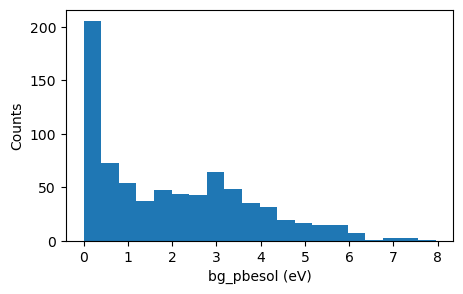

In [12]:
# Plot train histogram
plt.figure(figsize=(5,3))
plt.hist(df_train[TARGET_COL], bins=20)
plt.xlabel(f'{TARGET_COL}')
plt.ylabel('Counts')
# plt.xlim(0, 0.61)
plt.show()

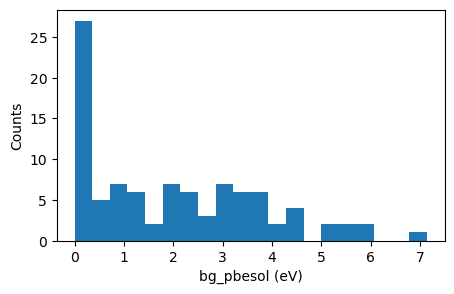

In [13]:
# Plot test histogram
plt.figure(figsize=(5,3))
plt.hist(df_test[TARGET_COL], bins=20)
plt.xlabel(f'{TARGET_COL}')
plt.ylabel('Counts')
# plt.xlim(0, 0.61)
plt.show()

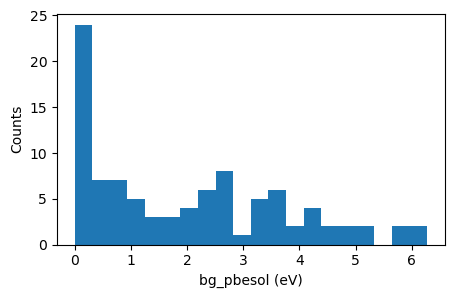

In [14]:
# Plot val histogram
plt.figure(figsize=(5,3))
plt.hist(df_val[TARGET_COL], bins=20)
plt.xlabel(f'{TARGET_COL}')
plt.ylabel('Counts')
# plt.xlim(0, 0.61)
plt.show()

# Baseline

### Train models

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
# Grid search CV
param_grid = {
    'n_estimators': [100],
    'max_depth': [3, 4, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.8],
}

rf = RandomForestRegressor(random_state=42)

search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print(f'Best CV r²: {search.best_score_:.3f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV r²: 0.692


In [17]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error', 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features=0.8,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train,y_train)
joblib.dump(rf, 'models/rf/bg_id/rf_pbesol_bg_id.pkl')

['models/rf/bg_id/rf_pbesol_bg_id.pkl']

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
# Grid search CV
param_grid = {
    'kernel': ['laplacian'],
    'gamma': [0.0001, 0.001, 0.01],
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],  # push alpha higher
}

search = GridSearchCV(
    KernelRidge(),
    param_grid,
    cv=10,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
print('Best params:', search.best_params_)
print(f'Best CV r²: {search.best_score_:.3f}')

Fitting 10 folds for each of 15 candidates, totalling 150 fits
Best params: {'alpha': 0.1, 'gamma': 0.01, 'kernel': 'laplacian'}
Best CV r²: 0.696


In [21]:
from sklearn.kernel_ridge import KernelRidge
kr = KernelRidge(
    alpha=0.1,
    gamma=0.01,
    kernel='laplacian',
)
kr.fit(X_train,y_train)
joblib.dump(kr, 'models/kr/bg_id/kr_pbesol_bg_id.pkl')

['models/kr/bg_id/kr_pbesol_bg_id.pkl']

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
# Grid search CV
param_grid = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'min_child_weight': [3, 5, 10],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'reg_alpha': [0.1, 1.0, 5.0],
    'reg_lambda': [1.0, 5.0, 10.0],
}

search = GridSearchCV(
    XGBRegressor(booster='gbtree'),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)
print(search.best_params_)
print(f'Best CV r²: {search.best_score_:.3f}')

In [23]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.6,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    n_estimators=500,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
)
xgb.fit(X_train,y_train)
joblib.dump(xgb, 'models/xgb/bg_id/xgb_pbesol_bg_id.pkl')

['models/xgb/bg_id/xgb_pbesol_bg_id.pkl']

In [24]:
from sklearn.ensemble import VotingRegressor
com = VotingRegressor(
    estimators=[
        ('rf', clone(rf)),
        ('xgb', clone(xgb)),
        ('kr', clone(kr)),
    ],
    n_jobs=-1,
)
com.fit(X_train,y_train)
joblib.dump(com, 'models/com/bg_id/com_pbesol_bg_id.pkl')

['models/com/bg_id/com_pbesol_bg_id.pkl']

### Evaluation

In [25]:
rf = joblib.load('models/rf/bg_id/rf_pbesol_bg_id.pkl') #RandomForestRegressor
kr = joblib.load('models/kr/bg_id/kr_pbesol_bg_id.pkl') #KernelRidge
xgb= joblib.load('models/xgb/bg_id/xgb_pbesol_bg_id.pkl') #XGBRegressor
com= joblib.load('models/com/bg_id/com_pbesol_bg_id.pkl') #Committee VotingRegressor of models above

In [26]:
# Score of the model
rf_pred_test = rf.predict(X_test)
rf_pred_val = rf.predict(X_val)
rf_score = {
    'mae_test': mean_absolute_error(y_test, rf_pred_test),
    'rmse_test': root_mean_squared_error(y_test, rf_pred_test),
    'r2_test':  r2_score(y_test, rf_pred_test),
    'mae_val': mean_absolute_error(y_val, rf_pred_val),
    'rmse_val':  root_mean_squared_error(y_val, rf_pred_val),
    'r2_val':   r2_score(y_val, rf_pred_val),
}
print(rf_score)

kr_pred_test = kr.predict(X_test)
kr_pred_val = kr.predict(X_val)
kr_score = {
    'mae_test': mean_absolute_error(y_test, kr_pred_test),
    'rmse_test': root_mean_squared_error(y_test, kr_pred_test),
    'r2_test': r2_score(y_test, kr_pred_test),
    'mae_val': mean_absolute_error(y_val, kr_pred_val),
    'rmse_val': root_mean_squared_error(y_val, kr_pred_val),
    'r2_val': r2_score(y_val, kr_pred_val),
}
print(kr_score)

xgb_pred_test = xgb.predict(X_test)
xgb_pred_val = xgb.predict(X_val)
xgb_score = {
    'mae_test': mean_absolute_error(y_test, xgb_pred_test),
    'rmse_test': root_mean_squared_error(y_test, xgb_pred_test),
    'r2_test': r2_score(y_test, xgb_pred_test),
    'mae_val': mean_absolute_error(y_val, xgb_pred_val),
    'rmse_val': root_mean_squared_error(y_val, xgb_pred_val),
    'r2_val': r2_score(y_val, xgb_pred_val),
}
print(xgb_score)

com_pred_test = com.predict(X_test)
com_pred_val = com.predict(X_val)
com_score = {
    'mae_test': mean_absolute_error(y_test, com_pred_test),
    'rmse_test': root_mean_squared_error(y_test, com_pred_test),
    'r2_test': r2_score(y_test, com_pred_test),
    'mae_val': mean_absolute_error(y_val, com_pred_val),
    'rmse_val': root_mean_squared_error(y_val, com_pred_val),
    'r2_val': r2_score(y_val, com_pred_val),
}
print(com_score)


{'mae_test': 0.6129701237357893, 'rmse_test': 0.8407786533310344, 'r2_test': 0.774453272284457, 'mae_val': 0.5951128503126314, 'rmse_val': 0.8094138033676629, 'r2_val': 0.7856725886261252}
{'mae_test': 0.5992956270038752, 'rmse_test': 0.8062202949542739, 'r2_test': 0.7926134294574801, 'mae_val': 0.5521045992465727, 'rmse_val': 0.7534724333990903, 'r2_val': 0.8142746260333167}
{'mae_test': 0.6028046085086933, 'rmse_test': 0.8120199468757331, 'r2_test': 0.7896189723051495, 'mae_val': 0.5241733799474052, 'rmse_val': 0.7148107701478239, 'r2_val': 0.8328452660002008}
{'mae_test': 0.573400831919933, 'rmse_test': 0.7819748393046637, 'r2_test': 0.8048993411245445, 'mae_val': 0.5342284649033315, 'rmse_val': 0.7347097559821406, 'r2_val': 0.8234091815650524}


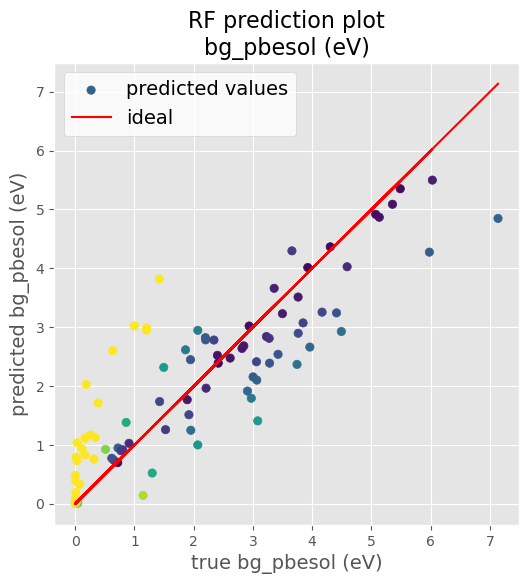

Training scores:
MAE = 0.6130
MSE = 0.7069
RMSE = 0.8408
r^2 = 0.7745


In [125]:
plot_prediction(X_test, y_test, rf, model_name='RF', name=TARGET_COL, save='models/rf/bg_id/plot_rf_pbesol_bg_id.png', format='png')

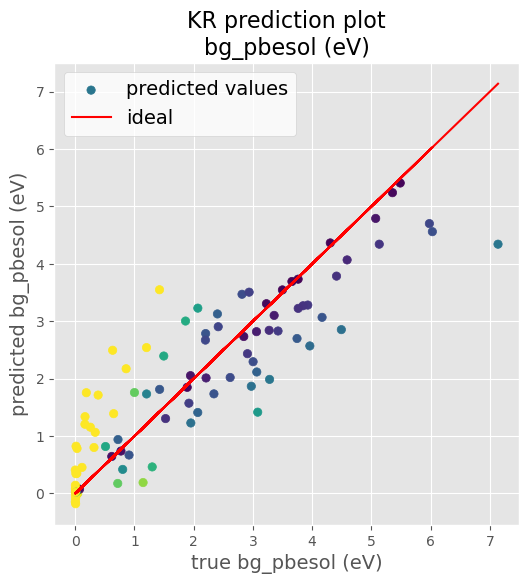

Training scores:
MAE = 0.5993
MSE = 0.6500
RMSE = 0.8062
r^2 = 0.7926


In [127]:
plot_prediction(X_test, y_test, kr, model_name='KR', name=TARGET_COL, save='models/kr/bg_id/plot_kr_pbesol_bg_id.pdf', format='pdf')

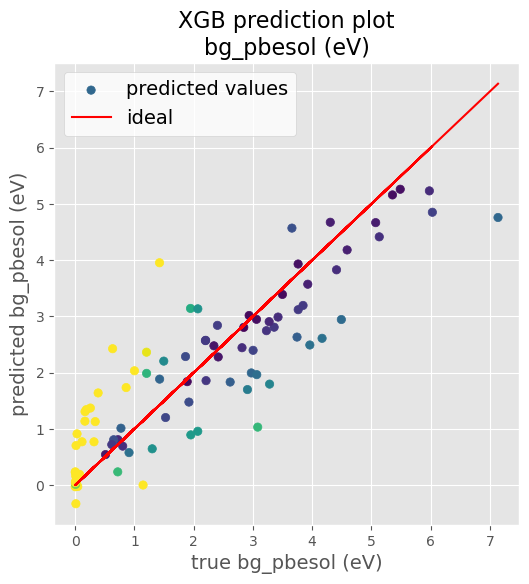

Training scores:
MAE = 0.6028
MSE = 0.6594
RMSE = 0.8120
r^2 = 0.7896


In [129]:
plot_prediction(X_test, y_test, xgb, model_name='XGB', name=TARGET_COL, save='models/xgb/bg_id/plot_xgb_pbesol_bg_id.pdf', format='pdf')

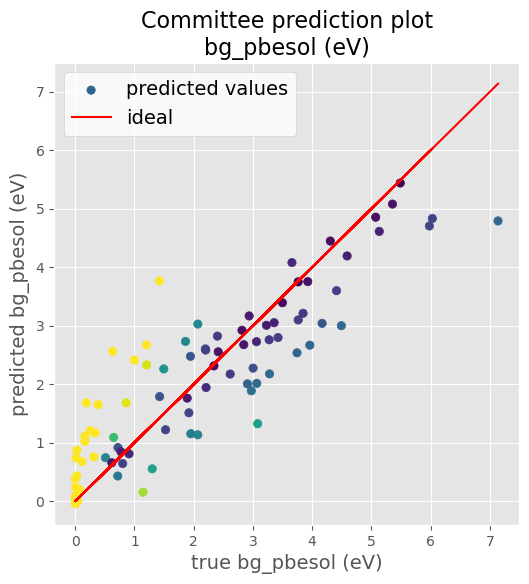

Training scores:
MAE = 0.5734
MSE = 0.6115
RMSE = 0.7820
r^2 = 0.8049


In [131]:
plot_prediction(X_test, y_test, com, model_name='Committee', name=TARGET_COL, save='models/com/bg_id/plot_com_pbesol_bg_id.pdf', format='pdf')

# AL Query strategies

In [70]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import RandomSampling
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_rnd(
    model,
    n_initial=60,
    batch_size=70,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Random sampling active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        rnd = RandomSampling(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            # 1. Train model
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
                
            if len(unlabeled_idx) == 0:    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query random samples
            query_idx = rnd.query(X=X_train, y=y_pool, batch_size=batch_size)
            
            y_pool[query_idx] = y_train[query_idx]
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
            )            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [71]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_unc(
    model,
    bagging_estimators=5,
    n_initial=60,
    batch_size=70,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Uncertainty sampling (Query-by-Committee Bagging Regressor) active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        bagging_estimators: Number of estimators in the bagging committee (int).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        qbc = QueryByCommittee(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_uncertainty': [],   # avg utility score of queried batch
            'max_uncertainty': [],   # highest utility in the queried batch
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
            
            # 1. Train committee
            ensemble = SklearnRegressor(
                BaggingRegressor(
                    estimator=reg,   
                    n_estimators=bagging_estimators,
                    bootstrap=True,
                    random_state=random_state,
                )
            )
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:
                history['mean_uncertainty'].append(0.0)
                history['max_uncertainty'].append(0.0)
                    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                    f'Uncertainty — mean: {0:.4f} eV  '
                    f'max: {0:.4f} eV'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query most uncertain samples
            query_idx, utilities = call_func(
                qbc.query,
                X=X_train,
                y=y_pool,
                reg=reg,
                ensemble=ensemble,
                fit_ensemble=True,
                batch_size=batch_size,
                return_utilities=True,
            )
            
            y_pool[query_idx] = y_train[query_idx]            
            
            queried_utilities = utilities[0, query_idx]  # shape (1, n_pool)        
            
            history['mean_uncertainty'].append(queried_utilities.mean())
            history['max_uncertainty'].append(queried_utilities.max())
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
                f'Uncertainty — mean: {np.sqrt(queried_utilities.mean()):.4f} eV  '
                f'max: {np.sqrt(queried_utilities.max()):.4f} eV'
            )

            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [72]:
from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def al_loop_qbc(
    model,
    n_initial=60,
    batch_size=70,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Uncertainty sampling (Query-by-Committee with heterogeneous models) active learning loop over a regression task.

    Args:
        models: Committee models of several base estimators (sklearn VotingRegressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── Query strategy ─────────────────────────────────────────────────────────────
        qbc = QueryByCommittee(random_state=random_state)
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_uncertainty': [],   # avg utility score of queried batch
            'max_uncertainty': [],   # highest utility in the queried batch
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
            
            # 1. Train committee
            ensemble = SklearnRegressor(
                estimator=reg, random_state=random_state
            )
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:
                history['mean_uncertainty'].append(0.0)
                history['max_uncertainty'].append(0.0)
                    
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                    f'Uncertainty — mean: {0:.4f} eV  '
                    f'max: {0:.4f} eV'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query most uncertain samples
            query_idx, utilities = call_func(
                qbc.query,
                X=X_train,
                y=y_pool,
                reg=reg,
                ensemble=ensemble,
                fit_ensemble=True,
                batch_size=batch_size,
                return_utilities=True,
            )
            
            y_pool[query_idx] = y_train[query_idx]            
            
            queried_utilities = utilities[0, query_idx]  # shape (1, n_pool)        
            
            history['mean_uncertainty'].append(queried_utilities.mean())
            history['max_uncertainty'].append(queried_utilities.max())
                
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
                f'Uncertainty — mean: {np.sqrt(queried_utilities.mean()):.4f} eV  '
                f'max: {np.sqrt(queried_utilities.max()):.4f} eV'
            )

            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [73]:
from sklearn.base import clone
from skactiveml.regressor import SklearnRegressor
from skactiveml.utils import MISSING_LABEL, labeled_indices, unlabeled_indices, call_func

def diversity_query(
    X_train: np.ndarray,
    y_pool: np.ndarray,
    batch_size: int,
):
    '''
    Select a batch of unlabeled samples using greedy MaxMin diversity sampling with Tanimoto distance.

    Args:
        X_train: Training feature matrix with only fingerprints (np.ndarray).
        y_pool: Current label pool. Unlabeled entries are marked with MISSING_LABEL (np.ndarray).
        batch_size: Number of samples to select (int).
    Returns:
        query_idx: Queried indices, ordered from most to least diverse (np.ndarray).
        utilities:
            - div_mean_pool: Mean Tanimoto distance of all unlabeled points to their nearest labeled neighbour.
            - div_max_pool: Maximum Tanimoto distance in the unlabeled pool, i.e. the distance of the most underexplored point.
    '''
    labeled_idx   = labeled_indices(y_pool)
    unlabeled_idx = unlabeled_indices(y_pool)

    if len(unlabeled_idx) == 0:
        return np.array([], dtype=int), {}

    actual_batch = min(batch_size, len(unlabeled_idx))

    # binarize once, float32 halves memory + speeds up BLAS
    X_u = (X_train[unlabeled_idx] > 0).astype(np.float32)
    X_l = (X_train[labeled_idx]   > 0).astype(np.float32)

    # precompute norms once — reused in every greedy step
    norms_u = X_u.sum(axis=1)  # (n_unlabeled,)
    norms_l = X_l.sum(axis=1)  # (n_labeled,)

    # initial max similarity to labeled set — single matmul
    dot   = X_u @ X_l.T                              # (n_u, n_l)
    union = norms_u[:, None] + norms_l[None, :] - dot
    np.maximum(union, 1e-10, out=union)               # in-place, no allocation
    max_sim = (dot / union).max(axis=1)               # (n_u,)
    del dot, union                                    # free memory immediately

    dist_orig = 1.0 - max_sim.copy()

    selected_local: list[int] = []

    for _ in range(actual_batch):
        best = int(np.argmin(max_sim))
        selected_local.append(best)
        max_sim[best] = np.inf

        if len(selected_local) < actual_batch:
            # matvec (n_u × d) instead of matmul (n_u × n_u) — much cheaper
            dot_new   = X_u @ X_u[best]              # (n_u,)
            union_new = norms_u + norms_u[best] - dot_new
            np.maximum(union_new, 1e-10, out=union_new)
            np.maximum(max_sim, dot_new / union_new, out=max_sim)

    utilities = {
        'mean_diversity': float(dist_orig.mean()),
        'max_diversity':  float(dist_orig.max()),
    }

    return unlabeled_idx[np.array(selected_local)], utilities
    
def al_loop_div(
    model,
    n_initial=7106,
    batch_size=5000,
    n_cycles=None,
    random_state=42,
    n_runs=1,
    save=None,
):
    '''
    Run a Diversity sampling (Tanimoto distance) active learning loop over a regression task.

    Args:
        model: Base estimator to train and wrap in a BaggingRegressor committee (sklearn-compatible regressor).
        n_initial: Number of randomly selected initial samples (int).
        batch_size: Number of samples to query and label per cycle (int).
        n_cycles: Number of AL cycles to run, if None runs until the pool is exhausted (int or None).
        random_state: rng seed (int).
        n_runs: Number of independent runs with different initial labeled sets (int).
        save: File path to save the combined results, if None file is not saved (str or None).

    Returns:
        pd.DataFrame of all runs concatenated into a single flat DataFrame, with 'run' and 'cycle' columns for grouping.
    '''
    rng = np.random.default_rng(random_state)
    run_seeds = rng.integers(0, 2**31, size=n_runs)

    all_histories = []

    for run in range(n_runs):
        run_seed = run_seeds[run]
        run_rng = np.random.default_rng(run_seed)

        print(f'\n{'='*60}')
        print(f'Run {run + 1}/{n_runs}  (seed={run_seed})')
        print(f'{'='*60}')
        
        # ── Label pool ─────────────────────────────────────────────────────────────────
        y_pool = np.full(len(X_train), MISSING_LABEL)
        initial_idx = rng.choice(len(X_train), size=n_initial, replace=False)
        y_pool[initial_idx] = y_train[initial_idx]
        
        # ── History ────────────────────────────────────────────────────────────────────
        history = {
            'run': [],
            'cycle': [],
            'n_labeled': [],
            'mae_test': [],
            'mse_test': [],
            'rmse_test': [],
            'r2_test': [],
            'mae_val': [],
            'mse_val': [],
            'rmse_val': [],
            'r2_val': [],
            'mean_diversity': [],
            'max_diversity': [],
            'queried_idx': [],
        }
        
        reg = clone(model)
    
        if n_cycles is None:
            n_cycles = math.ceil((len(X_train)-n_initial)/batch_size) + 1
        
        # ── Active-learning loop ───────────────────────────────────────────────────────
        for cycle in range(n_cycles):
            labeled_idx = labeled_indices(y_pool)
            unlabeled_idx = unlabeled_indices(y_pool)
            n_labeled = len(labeled_indices(y_pool))           
        
            # 1. Train model
            reg.fit(X_train[labeled_idx], y_pool[labeled_idx])
        
            # 2. Record
            y_pred_test = reg.predict(X_test)
            y_pred_val = reg.predict(X_val)
            
            mae_test = mean_absolute_error(y_test, y_pred_test)
            mse_test = mean_squared_error(y_test, y_pred_test)
            rmse_test = root_mean_squared_error(y_test, y_pred_test)
            r2_test = r2_score(y_test, y_pred_test)
        
            mae_val = mean_absolute_error(y_val, y_pred_val)
            mse_val = mean_squared_error(y_val, y_pred_val)
            rmse_val = root_mean_squared_error(y_val, y_pred_val)
            r2_val = r2_score(y_val, y_pred_val)

            history['run'].append(run+1)
            history['cycle'].append(cycle+1)
            history['n_labeled'].append(n_labeled)
            history['mae_test'].append(mae_test)
            history['mse_test'].append(mse_test)
            history['rmse_test'].append(rmse_test)
            history['r2_test'].append(r2_test)
            history['mae_val'].append(mae_val)
            history['mse_val'].append(mse_val)
            history['rmse_val'].append(rmse_val)
            history['r2_val'].append(r2_val)

            if cycle == 0:
                history['queried_idx'].append(initial_idx.tolist())
            else:
                history['queried_idx'].append(query_idx.tolist())
            
            if len(unlabeled_idx) == 0:    
                history['mean_diversity'].append(0.0)
                history['max_diversity'].append(0.0)
                
                print(
                    f'Cycle {cycle + 1:>2} | '
                    f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                    f'MAE: {mae_test:.4f} eV | '
                    f'RMSE: {rmse_test:.4f} eV | '
                    f'R2: {r2_test:.4f} | '
                    f'Diversity — mean: {0:.4f} eV  '
                    f'max: {0:.4f} eV'
                )
                print('All pool samples labeled.')
                break
                
            # 3. Query random samples
            query_idx, utilities = diversity_query(X_train[:, (slice(len(features), None))], y_pool, batch_size)
            
            y_pool[query_idx] = y_train[query_idx]

            history['mean_diversity'].append(utilities['mean_diversity'])
            history['max_diversity'].append(utilities['max_diversity'])
            
            print(
                f'Cycle {cycle + 1:>2} | '
                f'Labeled: {n_labeled:>5}/{len(X_train)} | '
                f'MAE: {mae_test:.4f} eV | '
                f'RMSE: {rmse_test:.4f} eV | '
                f'R2: {r2_test:.4f} | '
                f'Diversity — mean: {utilities['mean_diversity']:.4f}  '
                f'max: {utilities['max_diversity']:.4f}'
            )            
            
        print(f'\nDone. Final labeled count: {labeled_indices(y_pool).size}/{len(X_train)}')
        
        all_histories.append(history)

    df = pd.concat([pd.DataFrame(h) for h in all_histories], ignore_index=True)
    if save is not None:
        df.to_csv(save, index=False)
    
    return df

In [73]:
al_loop_rnd(rf, n_runs=5, save='active_learning/rf/bg_id/al_history_rf_rnd_pbesol_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 0.9723 eV | RMSE: 1.2342 eV | R2: 0.5140 | 
Cycle  2 | Labeled:   130/760 | MAE: 0.8149 eV | RMSE: 1.0874 eV | R2: 0.6227 | 
Cycle  3 | Labeled:   200/760 | MAE: 0.7397 eV | RMSE: 0.9494 eV | R2: 0.7124 | 
Cycle  4 | Labeled:   270/760 | MAE: 0.7368 eV | RMSE: 0.9765 eV | R2: 0.6958 | 
Cycle  5 | Labeled:   340/760 | MAE: 0.6863 eV | RMSE: 0.9011 eV | R2: 0.7409 | 
Cycle  6 | Labeled:   410/760 | MAE: 0.6671 eV | RMSE: 0.8856 eV | R2: 0.7498 | 
Cycle  7 | Labeled:   480/760 | MAE: 0.6640 eV | RMSE: 0.8592 eV | R2: 0.7645 | 
Cycle  8 | Labeled:   550/760 | MAE: 0.6424 eV | RMSE: 0.8511 eV | R2: 0.7689 | 
Cycle  9 | Labeled:   620/760 | MAE: 0.6313 eV | RMSE: 0.8245 eV | R2: 0.7831 | 
Cycle 10 | Labeled:   690/760 | MAE: 0.6473 eV | RMSE: 0.8460 eV | R2: 0.7716 | 
Cycle 11 | Labeled:   760/760 | MAE: 0.6130 eV | RMSE: 0.8408 eV | R2: 0.7745 | 
All pool samples labeled.

Done. Final labeled count: 760/760

Run 2/5  (seed=1662

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,60,0.972258,1.523177,1.234171,0.514014,1.018246,1.670981,1.292664,0.453352,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.814892,1.182426,1.087394,0.622735,0.852494,1.307794,1.143588,0.572165,"[542, 348, 23, 458, 10, 54, 324, 444, 195, 578..."
2,1,3,200,0.739709,0.901319,0.949378,0.712425,0.796901,1.114190,1.055552,0.635502,"[426, 462, 63, 605, 216, 278, 264, 13, 418, 49..."
3,1,4,270,0.736850,0.953472,0.976459,0.695785,0.745326,0.974738,0.987288,0.681122,"[491, 505, 690, 574, 732, 43, 636, 212, 442, 7..."
4,1,5,340,0.686298,0.811976,0.901097,0.740931,0.693257,0.927734,0.963189,0.696499,"[144, 115, 53, 454, 102, 408, 481, 207, 577, 2..."
5,1,6,410,0.667078,0.784280,0.885596,0.749767,0.671748,0.822545,0.906943,0.730911,"[441, 208, 148, 511, 81, 196, 743, 83, 445, 57..."
6,1,7,480,0.663986,0.738248,0.859214,0.764454,0.644123,0.818736,0.904840,0.732157,"[163, 173, 151, 645, 610, 555, 248, 154, 222, ..."
7,1,8,550,0.642360,0.724313,0.851066,0.768900,0.643813,0.770925,0.878023,0.747798,"[198, 684, 29, 713, 94, 363, 683, 476, 469, 52..."
8,1,9,620,0.631319,0.679850,0.824530,0.783087,0.593861,0.670288,0.818711,0.780720,"[41, 236, 9, 622, 740, 114, 489, 84, 73, 443, ..."
9,1,10,690,0.647304,0.715753,0.846022,0.771631,0.607076,0.684097,0.827101,0.776203,"[573, 538, 640, 340, 294, 712, 275, 380, 457, ..."


In [74]:
al_loop_unc(rf, n_runs=5, save='active_learning/rf/bg_id/al_history_rf_unc_pbesol_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 0.9723 eV | RMSE: 1.2342 eV | R2: 0.5140 | Uncertainty — mean: 0.8422 eV  max: 0.9710 eV
Cycle  2 | Labeled:   130/760 | MAE: 0.9377 eV | RMSE: 1.2621 eV | R2: 0.4918 | Uncertainty — mean: 0.7503 eV  max: 0.9509 eV
Cycle  3 | Labeled:   200/760 | MAE: 0.8196 eV | RMSE: 1.0349 eV | R2: 0.6583 | Uncertainty — mean: 0.6972 eV  max: 0.8725 eV
Cycle  4 | Labeled:   270/760 | MAE: 0.7693 eV | RMSE: 0.9683 eV | R2: 0.7008 | Uncertainty — mean: 0.6958 eV  max: 0.8930 eV
Cycle  5 | Labeled:   340/760 | MAE: 0.7079 eV | RMSE: 0.9360 eV | R2: 0.7205 | Uncertainty — mean: 0.5909 eV  max: 0.7065 eV
Cycle  6 | Labeled:   410/760 | MAE: 0.6868 eV | RMSE: 0.9030 eV | R2: 0.7399 | Uncertainty — mean: 0.6003 eV  max: 0.7418 eV
Cycle  7 | Labeled:   480/760 | MAE: 0.6633 eV | RMSE: 0.8778 eV | R2: 0.7541 | Uncertainty — mean: 0.5268 eV  max: 0.6555 eV
Cycle  8 | Labeled:   550/760 | MAE: 0.6539 eV | RMSE: 0.8495 eV | R2: 0.7697 | Uncertainty

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,60,0.972258,1.523177,1.234171,0.514014,1.018246,1.670981,1.292664,0.453352,0.709256,0.942768,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.937708,1.592801,1.262062,0.491800,0.954887,1.441203,1.200501,0.528522,0.562977,0.904203,"[314, 234, 647, 57, 192, 388, 581, 43, 105, 82..."
2,1,3,200,0.819620,1.071102,1.034941,0.658254,0.859769,1.136523,1.066079,0.628195,0.486052,0.761195,"[0, 299, 325, 660, 107, 523, 487, 214, 671, 48..."
3,1,4,270,0.769300,0.937629,0.968312,0.700840,0.785900,0.976995,0.988431,0.680384,0.484113,0.797383,"[528, 645, 354, 749, 185, 164, 429, 514, 103, ..."
4,1,5,340,0.707920,0.876080,0.935991,0.720478,0.740150,0.934548,0.966720,0.694270,0.349167,0.499085,"[625, 306, 230, 26, 174, 501, 664, 112, 111, 2..."
5,1,6,410,0.686815,0.815331,0.902957,0.739860,0.697283,0.861444,0.928140,0.718185,0.360348,0.550263,"[691, 723, 444, 84, 642, 223, 113, 729, 440, 4..."
6,1,7,480,0.663327,0.770596,0.877836,0.754133,0.671468,0.785855,0.886485,0.742914,0.277478,0.429650,"[118, 262, 583, 27, 726, 109, 585, 184, 593, 5..."
7,1,8,550,0.653932,0.721677,0.849516,0.769741,0.645692,0.727028,0.852659,0.762159,0.231513,0.485097,"[525, 291, 737, 172, 188, 11, 273, 266, 754, 7..."
8,1,9,620,0.650029,0.719957,0.848503,0.770290,0.605575,0.658721,0.811616,0.784505,0.181197,0.462665,"[347, 242, 725, 614, 621, 123, 503, 673, 419, ..."
9,1,10,690,0.611757,0.663884,0.814791,0.788181,0.621187,0.685394,0.827885,0.775779,0.068982,0.285534,"[455, 454, 646, 708, 217, 120, 400, 414, 215, ..."


In [75]:
al_loop_rnd(xgb, n_runs=5, save='active_learning/xgb/bg_id/al_history_xgb_rnd_pbesol_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 0.9008 eV | RMSE: 1.2025 eV | R2: 0.5386 | 
Cycle  2 | Labeled:   130/760 | MAE: 0.7511 eV | RMSE: 0.9944 eV | R2: 0.6845 | 
Cycle  3 | Labeled:   200/760 | MAE: 0.7099 eV | RMSE: 0.9587 eV | R2: 0.7067 | 
Cycle  4 | Labeled:   270/760 | MAE: 0.6631 eV | RMSE: 0.9056 eV | R2: 0.7383 | 
Cycle  5 | Labeled:   340/760 | MAE: 0.6085 eV | RMSE: 0.8034 eV | R2: 0.7941 | 
Cycle  6 | Labeled:   410/760 | MAE: 0.6040 eV | RMSE: 0.8063 eV | R2: 0.7926 | 
Cycle  7 | Labeled:   480/760 | MAE: 0.5978 eV | RMSE: 0.8236 eV | R2: 0.7836 | 
Cycle  8 | Labeled:   550/760 | MAE: 0.5648 eV | RMSE: 0.7659 eV | R2: 0.8128 | 
Cycle  9 | Labeled:   620/760 | MAE: 0.5636 eV | RMSE: 0.7658 eV | R2: 0.8129 | 
Cycle 10 | Labeled:   690/760 | MAE: 0.6029 eV | RMSE: 0.8041 eV | R2: 0.7937 | 
Cycle 11 | Labeled:   760/760 | MAE: 0.6028 eV | RMSE: 0.8120 eV | R2: 0.7896 | 
All pool samples labeled.

Done. Final labeled count: 760/760

Run 2/5  (seed=1662

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,60,0.900793,1.446022,1.202506,0.538631,0.937503,1.565057,1.251022,0.488004,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.751085,0.988778,0.994373,0.684520,0.780131,1.106353,1.051833,0.638065,"[542, 348, 23, 458, 10, 54, 324, 444, 195, 578..."
2,1,3,200,0.709897,0.919198,0.958748,0.706720,0.709243,0.911731,0.954846,0.701734,"[426, 462, 63, 605, 216, 278, 264, 13, 418, 49..."
3,1,4,270,0.663140,0.820134,0.905613,0.738327,0.657425,0.784412,0.885671,0.743386,"[491, 505, 690, 574, 732, 43, 636, 212, 442, 7..."
4,1,5,340,0.608533,0.645459,0.803404,0.794060,0.618711,0.761407,0.872587,0.750912,"[144, 115, 53, 454, 102, 408, 481, 207, 577, 2..."
5,1,6,410,0.603965,0.650160,0.806325,0.792559,0.635453,0.757319,0.870241,0.752249,"[441, 208, 148, 511, 81, 196, 743, 83, 445, 57..."
6,1,7,480,0.597837,0.678298,0.823588,0.783582,0.595762,0.659980,0.812392,0.784093,"[163, 173, 151, 645, 610, 555, 248, 154, 222, ..."
7,1,8,550,0.564796,0.586608,0.765903,0.812837,0.575363,0.630895,0.794289,0.793608,"[198, 684, 29, 713, 94, 363, 683, 476, 469, 52..."
8,1,9,620,0.563571,0.586455,0.765803,0.812885,0.578619,0.613271,0.783116,0.799373,"[41, 236, 9, 622, 740, 114, 489, 84, 73, 443, ..."
9,1,10,690,0.602876,0.646638,0.804138,0.793683,0.539048,0.537932,0.733438,0.824020,"[573, 538, 640, 340, 294, 712, 275, 380, 457, ..."


In [76]:
al_loop_unc(xgb, n_runs=5, save='active_learning/xgb/bg_id/al_history_xgb_unc_pbesol_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 0.9008 eV | RMSE: 1.2025 eV | R2: 0.5386 | Uncertainty — mean: 0.9404 eV  max: 1.1006 eV
Cycle  2 | Labeled:   130/760 | MAE: 0.8269 eV | RMSE: 1.1549 eV | R2: 0.5744 | Uncertainty — mean: 0.9040 eV  max: 1.1142 eV
Cycle  3 | Labeled:   200/760 | MAE: 0.7558 eV | RMSE: 0.9893 eV | R2: 0.6878 | Uncertainty — mean: 0.8090 eV  max: 0.9447 eV
Cycle  4 | Labeled:   270/760 | MAE: 0.7156 eV | RMSE: 0.9350 eV | R2: 0.7211 | Uncertainty — mean: 0.7227 eV  max: 0.9318 eV
Cycle  5 | Labeled:   340/760 | MAE: 0.6617 eV | RMSE: 0.8679 eV | R2: 0.7596 | Uncertainty — mean: 0.7323 eV  max: 0.9072 eV
Cycle  6 | Labeled:   410/760 | MAE: 0.6432 eV | RMSE: 0.8427 eV | R2: 0.7734 | Uncertainty — mean: 0.6581 eV  max: 0.9890 eV
Cycle  7 | Labeled:   480/760 | MAE: 0.6246 eV | RMSE: 0.8304 eV | R2: 0.7800 | Uncertainty — mean: 0.6038 eV  max: 0.8190 eV
Cycle  8 | Labeled:   550/760 | MAE: 0.5922 eV | RMSE: 0.7881 eV | R2: 0.8018 | Uncertainty

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,60,0.900793,1.446022,1.202506,0.538631,0.937503,1.565057,1.251022,0.488004,0.884369,1.211221,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.826860,1.333807,1.154905,0.574435,0.875654,1.389729,1.178868,0.545361,0.817142,1.241475,"[314, 421, 510, 176, 647, 235, 415, 306, 192, ..."
2,1,3,200,0.755761,0.978641,0.989263,0.687754,0.789366,1.022380,1.011128,0.665536,0.654474,0.892373,"[499, 598, 511, 468, 81, 755, 557, 605, 318, 1..."
3,1,4,270,0.715558,0.874167,0.934969,0.721088,0.754386,0.975719,0.987785,0.680801,0.522347,0.868299,"[540, 528, 227, 640, 153, 133, 85, 56, 418, 37..."
4,1,5,340,0.661677,0.753337,0.867950,0.759640,0.657091,0.764453,0.874330,0.749915,0.536331,0.823016,"[583, 616, 243, 113, 513, 55, 671, 143, 729, 3..."
5,1,6,410,0.643223,0.710062,0.842652,0.773447,0.652963,0.744652,0.862932,0.756393,0.433092,0.978154,"[273, 642, 471, 629, 79, 740, 728, 454, 167, 5..."
6,1,7,480,0.624570,0.689647,0.830450,0.779961,0.584097,0.638876,0.799297,0.790997,0.364535,0.670700,"[548, 354, 399, 382, 174, 378, 268, 172, 74, 1..."
7,1,8,550,0.592213,0.621122,0.788113,0.801824,0.577719,0.578347,0.760491,0.810798,0.350229,0.701424,"[727, 280, 500, 191, 410, 242, 585, 323, 435, ..."
8,1,9,620,0.611529,0.673008,0.820371,0.785270,0.554634,0.549870,0.741532,0.820114,0.228369,0.384067,"[559, 69, 241, 455, 372, 706, 107, 275, 299, 1..."
9,1,10,690,0.593329,0.656724,0.810385,0.790465,0.540039,0.531804,0.729249,0.826024,0.129115,0.334870,"[453, 205, 680, 115, 633, 385, 618, 99, 469, 1..."


In [77]:
al_loop_rnd(kr, n_runs=5, save='active_learning/kr/bg_id/al_history_kr_rnd_pbesol_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 0.8267 eV | RMSE: 1.0802 eV | R2: 0.6277 | 
Cycle  2 | Labeled:   130/760 | MAE: 0.6861 eV | RMSE: 0.8985 eV | R2: 0.7424 | 
Cycle  3 | Labeled:   200/760 | MAE: 0.6353 eV | RMSE: 0.8672 eV | R2: 0.7600 | 
Cycle  4 | Labeled:   270/760 | MAE: 0.6247 eV | RMSE: 0.8433 eV | R2: 0.7731 | 
Cycle  5 | Labeled:   340/760 | MAE: 0.5976 eV | RMSE: 0.7993 eV | R2: 0.7962 | 
Cycle  6 | Labeled:   410/760 | MAE: 0.5921 eV | RMSE: 0.8007 eV | R2: 0.7954 | 
Cycle  7 | Labeled:   480/760 | MAE: 0.6027 eV | RMSE: 0.8163 eV | R2: 0.7874 | 
Cycle  8 | Labeled:   550/760 | MAE: 0.5880 eV | RMSE: 0.7973 eV | R2: 0.7972 | 
Cycle  9 | Labeled:   620/760 | MAE: 0.5915 eV | RMSE: 0.8026 eV | R2: 0.7945 | 
Cycle 10 | Labeled:   690/760 | MAE: 0.5897 eV | RMSE: 0.8018 eV | R2: 0.7949 | 
Cycle 11 | Labeled:   760/760 | MAE: 0.5993 eV | RMSE: 0.8062 eV | R2: 0.7926 | 
All pool samples labeled.

Done. Final labeled count: 760/760

Run 2/5  (seed=1662

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,60,0.826655,1.166926,1.080243,0.627680,0.890401,1.361644,1.166895,0.554549,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.686054,0.807351,0.898527,0.742406,0.695331,0.937957,0.968482,0.693155,"[542, 348, 23, 458, 10, 54, 324, 444, 195, 578..."
2,1,3,200,0.635275,0.752118,0.867247,0.760029,0.665991,0.830270,0.911192,0.728384,"[426, 462, 63, 605, 216, 278, 264, 13, 418, 49..."
3,1,4,270,0.624750,0.711112,0.843275,0.773112,0.624543,0.746938,0.864256,0.755645,"[491, 505, 690, 574, 732, 43, 636, 212, 442, 7..."
4,1,5,340,0.597598,0.638830,0.799268,0.796175,0.615694,0.733866,0.856660,0.759922,"[144, 115, 53, 454, 102, 408, 481, 207, 577, 2..."
5,1,6,410,0.592120,0.641190,0.800743,0.795422,0.598472,0.699854,0.836573,0.771048,"[441, 208, 148, 511, 81, 196, 743, 83, 445, 57..."
6,1,7,480,0.602681,0.666402,0.816334,0.787377,0.576431,0.640650,0.800406,0.790416,"[163, 173, 151, 645, 610, 555, 248, 154, 222, ..."
7,1,8,550,0.588030,0.635620,0.797258,0.797199,0.570574,0.620631,0.787801,0.796966,"[198, 684, 29, 713, 94, 363, 683, 476, 469, 52..."
8,1,9,620,0.591535,0.644149,0.802589,0.794477,0.562094,0.572583,0.756692,0.812684,"[41, 236, 9, 622, 740, 114, 489, 84, 73, 443, ..."
9,1,10,690,0.589708,0.642883,0.801800,0.794881,0.565010,0.582680,0.763335,0.809381,"[573, 538, 640, 340, 294, 712, 275, 380, 457, ..."


In [78]:
al_loop_unc(kr, n_runs=5, save='active_learning/kr/bg_id/al_history_kr_unc_pbesol_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 0.8267 eV | RMSE: 1.0802 eV | R2: 0.6277 | Uncertainty — mean: 0.7872 eV  max: 1.0526 eV
Cycle  2 | Labeled:   130/760 | MAE: 0.7943 eV | RMSE: 1.0536 eV | R2: 0.6458 | Uncertainty — mean: 0.7207 eV  max: 1.1487 eV
Cycle  3 | Labeled:   200/760 | MAE: 0.7678 eV | RMSE: 0.9991 eV | R2: 0.6815 | Uncertainty — mean: 0.6439 eV  max: 0.8280 eV
Cycle  4 | Labeled:   270/760 | MAE: 0.7325 eV | RMSE: 0.9447 eV | R2: 0.7153 | Uncertainty — mean: 0.5700 eV  max: 0.6659 eV
Cycle  5 | Labeled:   340/760 | MAE: 0.6862 eV | RMSE: 0.9111 eV | R2: 0.7351 | Uncertainty — mean: 0.6528 eV  max: 0.8480 eV
Cycle  6 | Labeled:   410/760 | MAE: 0.6322 eV | RMSE: 0.8631 eV | R2: 0.7623 | Uncertainty — mean: 0.5798 eV  max: 0.7869 eV
Cycle  7 | Labeled:   480/760 | MAE: 0.6217 eV | RMSE: 0.8257 eV | R2: 0.7825 | Uncertainty — mean: 0.5625 eV  max: 0.8225 eV
Cycle  8 | Labeled:   550/760 | MAE: 0.6111 eV | RMSE: 0.8150 eV | R2: 0.7881 | Uncertainty

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,60,0.826655,1.166926,1.080243,0.627680,0.890401,1.361644,1.166895,0.554549,0.619632,1.107894,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.794263,1.110117,1.053621,0.645805,0.818014,1.187864,1.089892,0.611400,0.519337,1.319558,"[556, 647, 598, 314, 553, 192, 361, 473, 189, ..."
2,1,3,200,0.767849,0.998111,0.999055,0.681542,0.805813,1.200003,1.095446,0.607429,0.414634,0.685650,"[56, 528, 187, 206, 506, 604, 468, 557, 29, 69..."
3,1,4,270,0.732521,0.892439,0.944690,0.715258,0.771546,1.068557,1.033710,0.650430,0.324902,0.443426,"[418, 177, 73, 685, 196, 521, 195, 492, 301, 5..."
4,1,5,340,0.686184,0.830101,0.911099,0.735147,0.760441,1.085969,1.042098,0.644734,0.426190,0.719127,"[401, 39, 256, 38, 79, 107, 331, 642, 117, 749..."
5,1,6,410,0.632165,0.744983,0.863124,0.762305,0.704480,0.875850,0.935868,0.713473,0.336192,0.619283,"[511, 374, 65, 106, 720, 410, 27, 542, 700, 65..."
6,1,7,480,0.621708,0.681699,0.825651,0.782497,0.596564,0.632499,0.795298,0.793083,0.316455,0.676558,"[170, 407, 524, 614, 264, 682, 393, 444, 548, ..."
7,1,8,550,0.611108,0.664166,0.814964,0.788091,0.596273,0.636026,0.797513,0.791929,0.251117,0.472123,"[133, 64, 390, 41, 442, 707, 636, 33, 178, 527..."
8,1,9,620,0.607992,0.655858,0.809851,0.790741,0.560306,0.575623,0.758698,0.811689,0.192890,0.380178,"[455, 480, 237, 405, 85, 580, 49, 45, 323, 535..."
9,1,10,690,0.605625,0.652124,0.807542,0.791933,0.563548,0.577993,0.760259,0.810914,0.105827,0.486731,"[297, 17, 699, 439, 584, 289, 75, 229, 623, 75..."


In [79]:
al_loop_rnd(com, n_runs=5, save='active_learning/com/bg_id/al_history_com_rnd_pbesol_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 0.8755 eV | RMSE: 1.1401 eV | R2: 0.5853 | 
Cycle  2 | Labeled:   130/760 | MAE: 0.7137 eV | RMSE: 0.9495 eV | R2: 0.7123 | 
Cycle  3 | Labeled:   200/760 | MAE: 0.6781 eV | RMSE: 0.9064 eV | R2: 0.7379 | 
Cycle  4 | Labeled:   270/760 | MAE: 0.6599 eV | RMSE: 0.8867 eV | R2: 0.7491 | 
Cycle  5 | Labeled:   340/760 | MAE: 0.6172 eV | RMSE: 0.8241 eV | R2: 0.7833 | 
Cycle  6 | Labeled:   410/760 | MAE: 0.5972 eV | RMSE: 0.8134 eV | R2: 0.7889 | 
Cycle  7 | Labeled:   480/760 | MAE: 0.6080 eV | RMSE: 0.8197 eV | R2: 0.7856 | 
Cycle  8 | Labeled:   550/760 | MAE: 0.5793 eV | RMSE: 0.7792 eV | R2: 0.8063 | 
Cycle  9 | Labeled:   620/760 | MAE: 0.5872 eV | RMSE: 0.7744 eV | R2: 0.8087 | 
Cycle 10 | Labeled:   690/760 | MAE: 0.5937 eV | RMSE: 0.7916 eV | R2: 0.8001 | 
Cycle 11 | Labeled:   760/760 | MAE: 0.5734 eV | RMSE: 0.7820 eV | R2: 0.8049 | 
All pool samples labeled.

Done. Final labeled count: 760/760

Run 2/5  (seed=1662

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,queried_idx
0,1,1,60,0.875458,1.299818,1.140096,0.585279,0.926253,1.487002,1.219427,0.513539,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.713673,0.901596,0.949524,0.712336,0.754673,1.060793,1.029948,0.652970,"[542, 348, 23, 458, 10, 54, 324, 444, 195, 578..."
2,1,3,200,0.678134,0.821555,0.906397,0.737874,0.700351,0.894151,0.945596,0.707486,"[426, 462, 63, 605, 216, 278, 264, 13, 418, 49..."
3,1,4,270,0.659854,0.786265,0.886716,0.749134,0.654758,0.806767,0.898202,0.736073,"[491, 505, 690, 574, 732, 43, 636, 212, 442, 7..."
4,1,5,340,0.617214,0.679119,0.824087,0.783320,0.618250,0.763898,0.874013,0.750097,"[144, 115, 53, 454, 102, 408, 481, 207, 577, 2..."
5,1,6,410,0.597166,0.661565,0.813366,0.788921,0.621361,0.731775,0.855438,0.760606,"[441, 208, 148, 511, 81, 196, 743, 83, 445, 57..."
6,1,7,480,0.607951,0.671833,0.819654,0.785644,0.581212,0.661884,0.813563,0.783470,"[163, 173, 151, 645, 610, 555, 248, 154, 222, ..."
7,1,8,550,0.579339,0.607170,0.779211,0.806276,0.553518,0.634147,0.796334,0.792544,"[198, 684, 29, 713, 94, 363, 683, 476, 469, 52..."
8,1,9,620,0.587216,0.599711,0.774410,0.808656,0.548721,0.576102,0.759014,0.811533,"[41, 236, 9, 622, 740, 114, 489, 84, 73, 443, ..."
9,1,10,690,0.593664,0.626661,0.791619,0.800057,0.540499,0.559563,0.748040,0.816943,"[573, 538, 640, 340, 294, 712, 275, 380, 457, ..."


In [80]:
al_loop_qbc(com, n_runs=5, save='active_learning/com/bg_id/al_history_com_qbc_pbesol_bg_id.csv')


Run 1/5  (seed=191664964)
Cycle  1 | Labeled:    60/760 | MAE: 0.8755 eV | RMSE: 1.1401 eV | R2: 0.5853 | Uncertainty — mean: 0.7914 eV  max: 1.0747 eV
Cycle  2 | Labeled:   130/760 | MAE: 0.8692 eV | RMSE: 1.1568 eV | R2: 0.5731 | Uncertainty — mean: 0.6416 eV  max: 0.8345 eV
Cycle  3 | Labeled:   200/760 | MAE: 0.7220 eV | RMSE: 0.9191 eV | R2: 0.7305 | Uncertainty — mean: 0.6189 eV  max: 0.8589 eV
Cycle  4 | Labeled:   270/760 | MAE: 0.6543 eV | RMSE: 0.8476 eV | R2: 0.7708 | Uncertainty — mean: 0.5734 eV  max: 0.6980 eV
Cycle  5 | Labeled:   340/760 | MAE: 0.6435 eV | RMSE: 0.8298 eV | R2: 0.7803 | Uncertainty — mean: 0.5319 eV  max: 0.7581 eV
Cycle  6 | Labeled:   410/760 | MAE: 0.6313 eV | RMSE: 0.8350 eV | R2: 0.7776 | Uncertainty — mean: 0.4935 eV  max: 0.7254 eV
Cycle  7 | Labeled:   480/760 | MAE: 0.6147 eV | RMSE: 0.8308 eV | R2: 0.7797 | Uncertainty — mean: 0.4703 eV  max: 0.6344 eV
Cycle  8 | Labeled:   550/760 | MAE: 0.5863 eV | RMSE: 0.7889 eV | R2: 0.8014 | Uncertainty

,run,cycle,n_labeled,mae_test,mse_test,rmse_test,r2_test,mae_val,mse_val,rmse_val,r2_val,mean_uncertainty,max_uncertainty,queried_idx
0,1,1,60,0.875458,1.299818,1.140096,0.585279,0.926253,1.487002,1.219427,0.513539,0.626378,1.155035,"[719, 509, 736, 594, 490, 116, 628, 60, 277, 5..."
1,1,2,130,0.869194,1.338123,1.156772,0.573058,0.842806,1.243913,1.115309,0.593064,0.411631,0.696437,"[511, 645, 597, 20, 744, 69, 326, 559, 95, 57,..."
2,1,3,200,0.721965,0.844755,0.919105,0.730472,0.727166,0.947221,0.973253,0.690124,0.382996,0.737695,"[56, 317, 598, 187, 528, 346, 18, 641, 403, 64..."
3,1,4,270,0.654297,0.718467,0.847624,0.770766,0.662714,0.890462,0.943643,0.708692,0.328830,0.487137,"[278, 602, 487, 687, 41, 341, 674, 30, 174, 87..."
4,1,5,340,0.643457,0.688579,0.829807,0.780302,0.624382,0.708792,0.841898,0.768124,0.282883,0.574750,"[700, 759, 230, 258, 657, 399, 302, 676, 348, ..."
5,1,6,410,0.631324,0.697164,0.834963,0.777562,0.593493,0.648469,0.805276,0.787858,0.243575,0.526223,"[506, 431, 169, 93, 85, 213, 166, 23, 114, 605..."
6,1,7,480,0.614714,0.690308,0.830848,0.779750,0.582466,0.648274,0.805155,0.787922,0.221221,0.402491,"[195, 523, 96, 354, 651, 296, 324, 310, 621, 7..."
7,1,8,550,0.586318,0.622300,0.788860,0.801449,0.563426,0.598699,0.773756,0.804140,0.170373,0.323470,"[527, 507, 699, 136, 132, 236, 716, 110, 345, ..."
8,1,9,620,0.589770,0.633455,0.795899,0.797890,0.554223,0.579954,0.761547,0.810273,0.117086,0.271032,"[747, 89, 424, 572, 158, 205, 384, 215, 245, 6..."
9,1,10,690,0.601758,0.660376,0.812635,0.789300,0.570238,0.608012,0.779752,0.801093,0.064236,0.206271,"[585, 610, 746, 669, 627, 480, 495, 251, 98, 6..."


In [83]:
rf_unc = df_groupby(pd.read_csv('active_learning/rf/bg_id/al_history_rf_unc_pbesol_bg_id.csv'))
rf_rnd = df_groupby(pd.read_csv('active_learning/rf/bg_id/al_history_rf_rnd_pbesol_bg_id.csv'))

xgb_unc = df_groupby(pd.read_csv('active_learning/xgb/bg_id/al_history_xgb_unc_pbesol_bg_id.csv'))
xgb_rnd = df_groupby(pd.read_csv('active_learning/xgb/bg_id/al_history_xgb_rnd_pbesol_bg_id.csv'))

kr_unc = df_groupby(pd.read_csv('active_learning/kr/bg_id/al_history_kr_unc_pbesol_bg_id.csv'))
kr_rnd = df_groupby(pd.read_csv('active_learning/kr/bg_id/al_history_kr_rnd_pbesol_bg_id.csv'))

com_unc = df_groupby(pd.read_csv('active_learning/com/bg_id/al_history_com_qbc_pbesol_bg_id.csv'))
com_rnd = df_groupby(pd.read_csv('active_learning/com/bg_id/al_history_com_rnd_pbesol_bg_id.csv'))

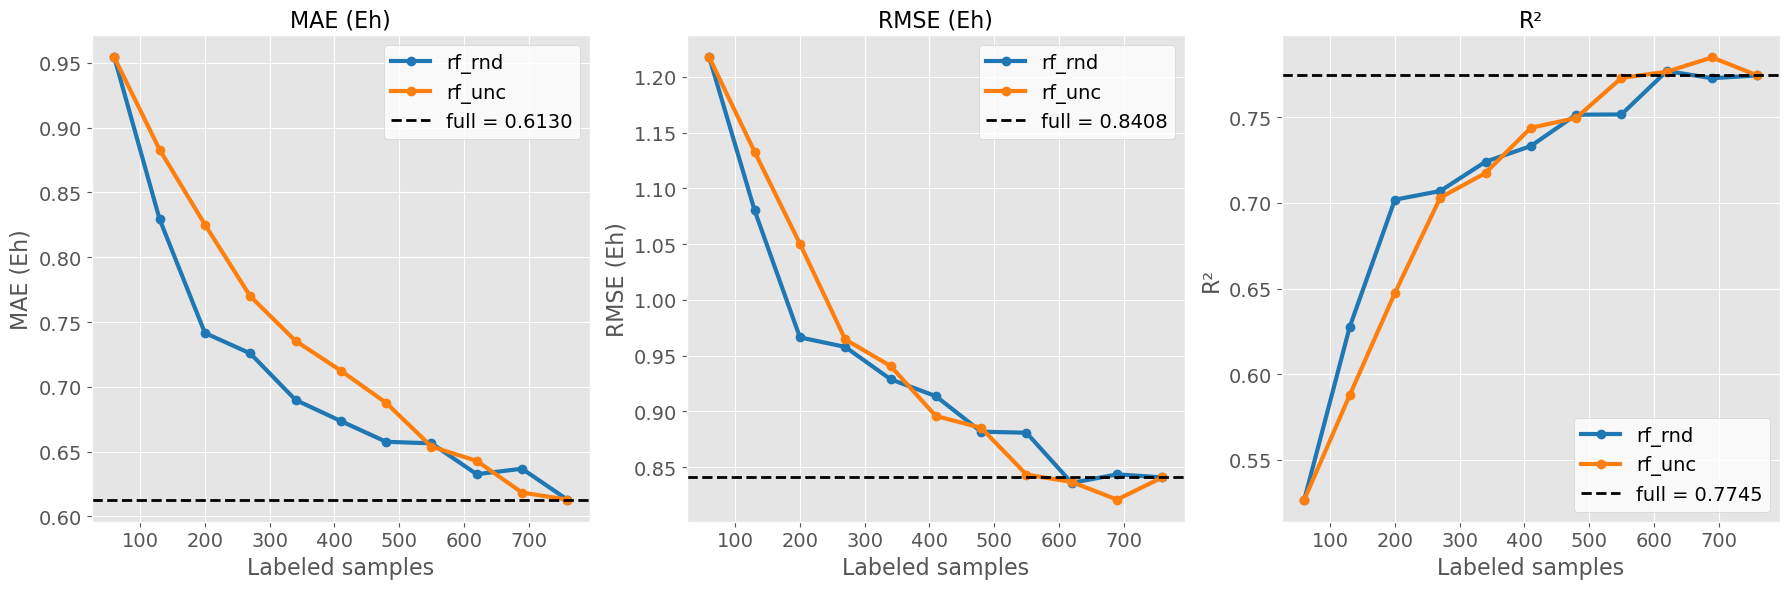

In [135]:
plot_al([rf_rnd, rf_unc], ['rf_rnd','rf_unc'], rf_score, save='active_learning/rf/bg_id/al_rf_pbesol_bg_id.pdf', format='pdf')

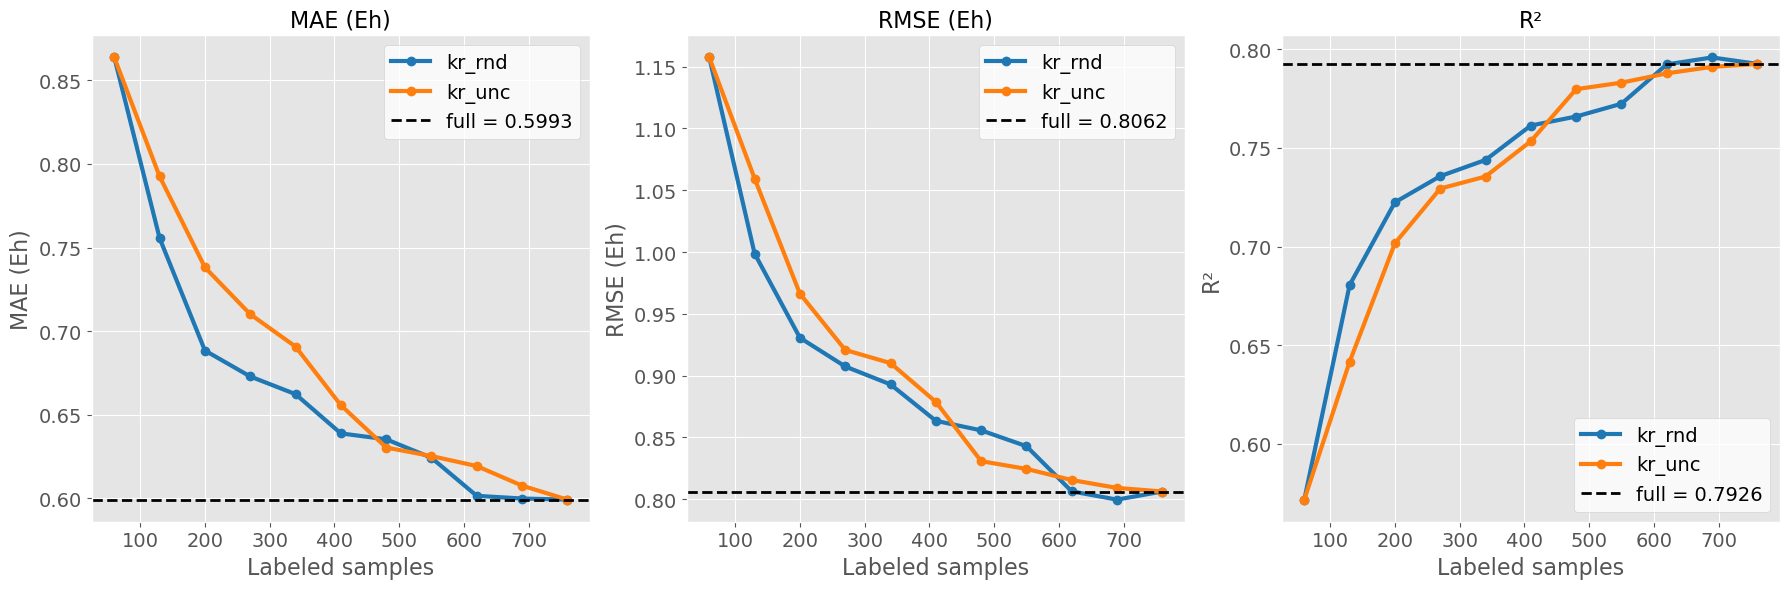

In [136]:
plot_al([kr_rnd, kr_unc], ['kr_rnd','kr_unc'], kr_score, save='active_learning/kr/bg_id/al_kr_pbesol_bg_id.pdf', format='pdf')

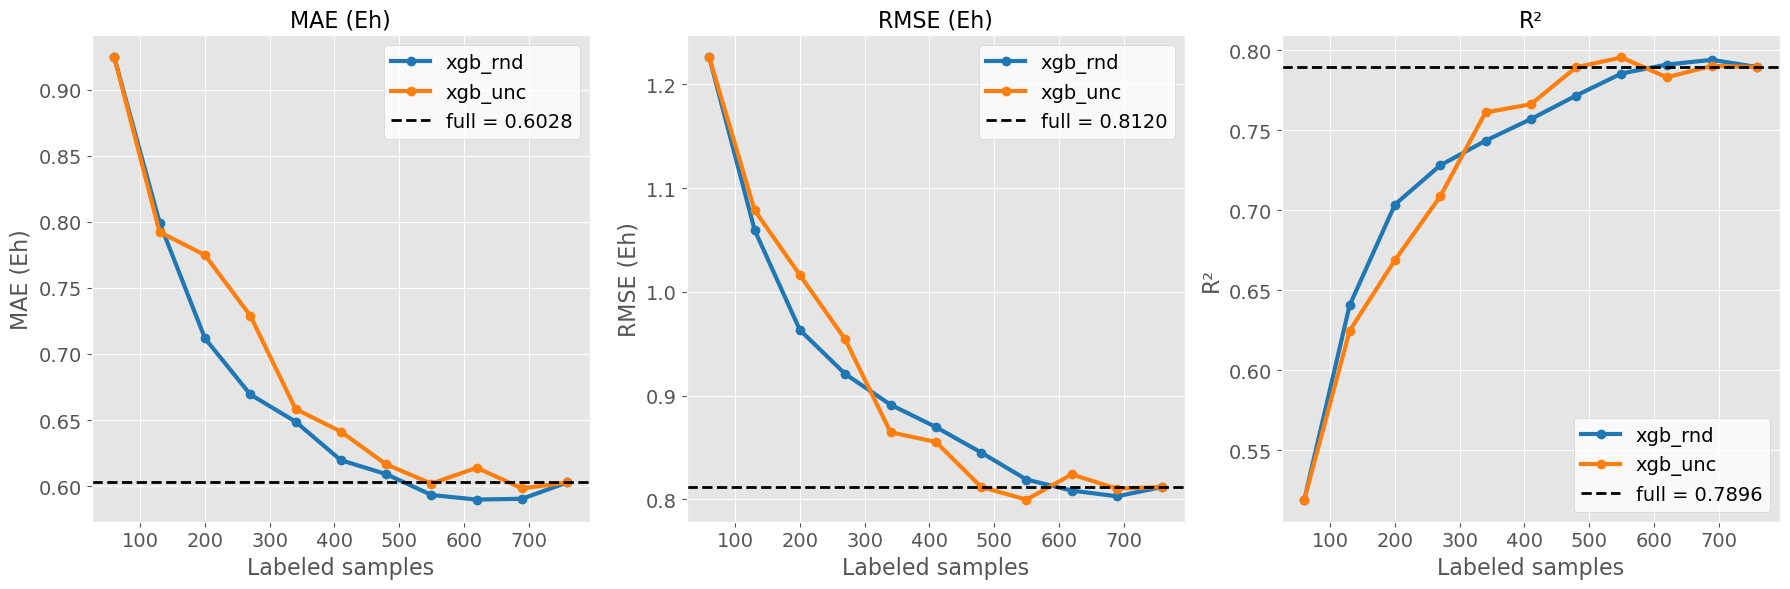

In [137]:
plot_al([xgb_rnd, xgb_unc], ['xgb_rnd','xgb_unc'], xgb_score, save='active_learning/xgb/bg_id/al_xgb_pbesol_bg_id.pdf', format='pdf')

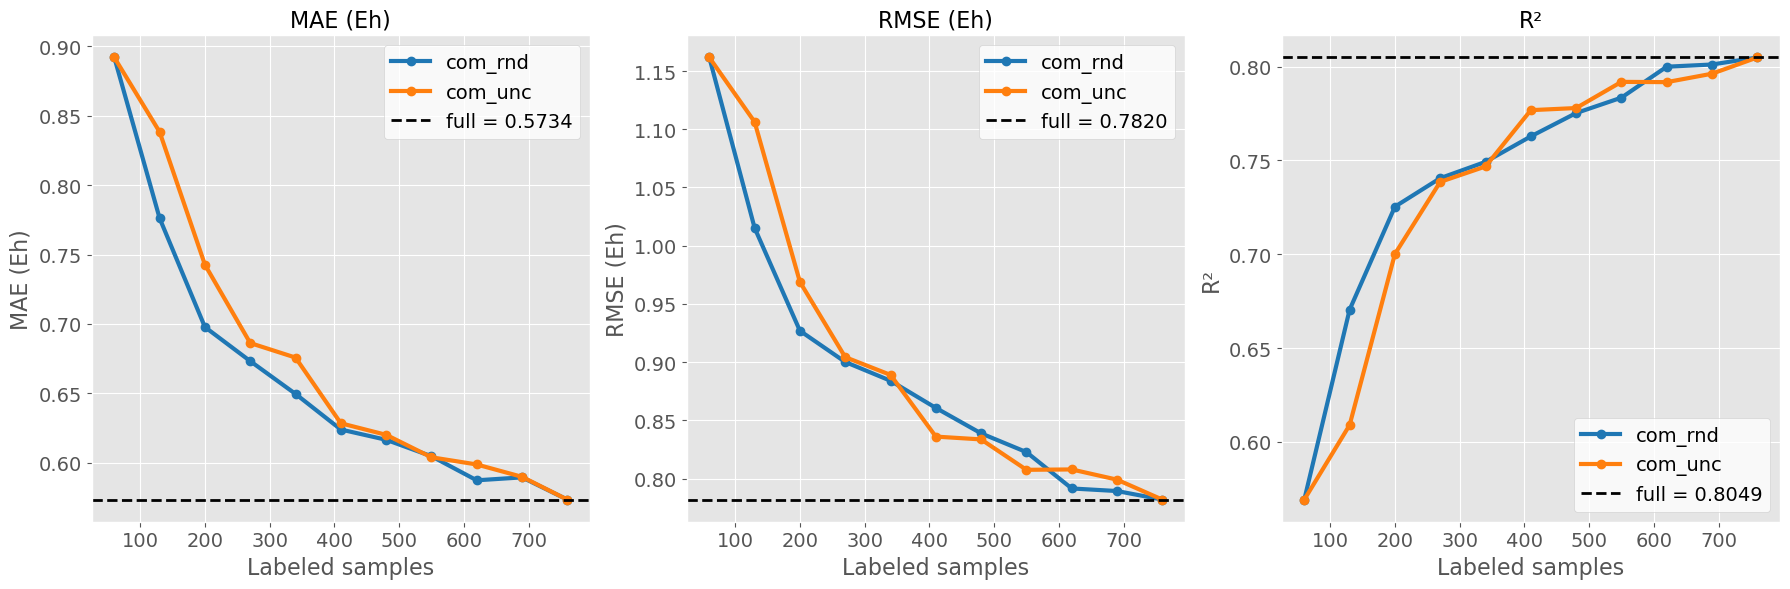

In [138]:
plot_al([com_rnd, com_unc], ['com_rnd','com_unc'], com_score, save='active_learning/com/bg_id/al_com_pbesol_bg_id.pdf', format='pdf')

In [20]:
import ast
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

print('Computing UMAP projection for X_train...')

reducer = umap.UMAP(
    n_neighbors=10, 
    min_dist=0.25, 
    metric='euclidean', 
    random_state=42
)
X_umap = reducer.fit_transform(X_train)

print('UMAP Projection complete.')

Computing UMAP projection for X_train...
UMAP Projection complete.


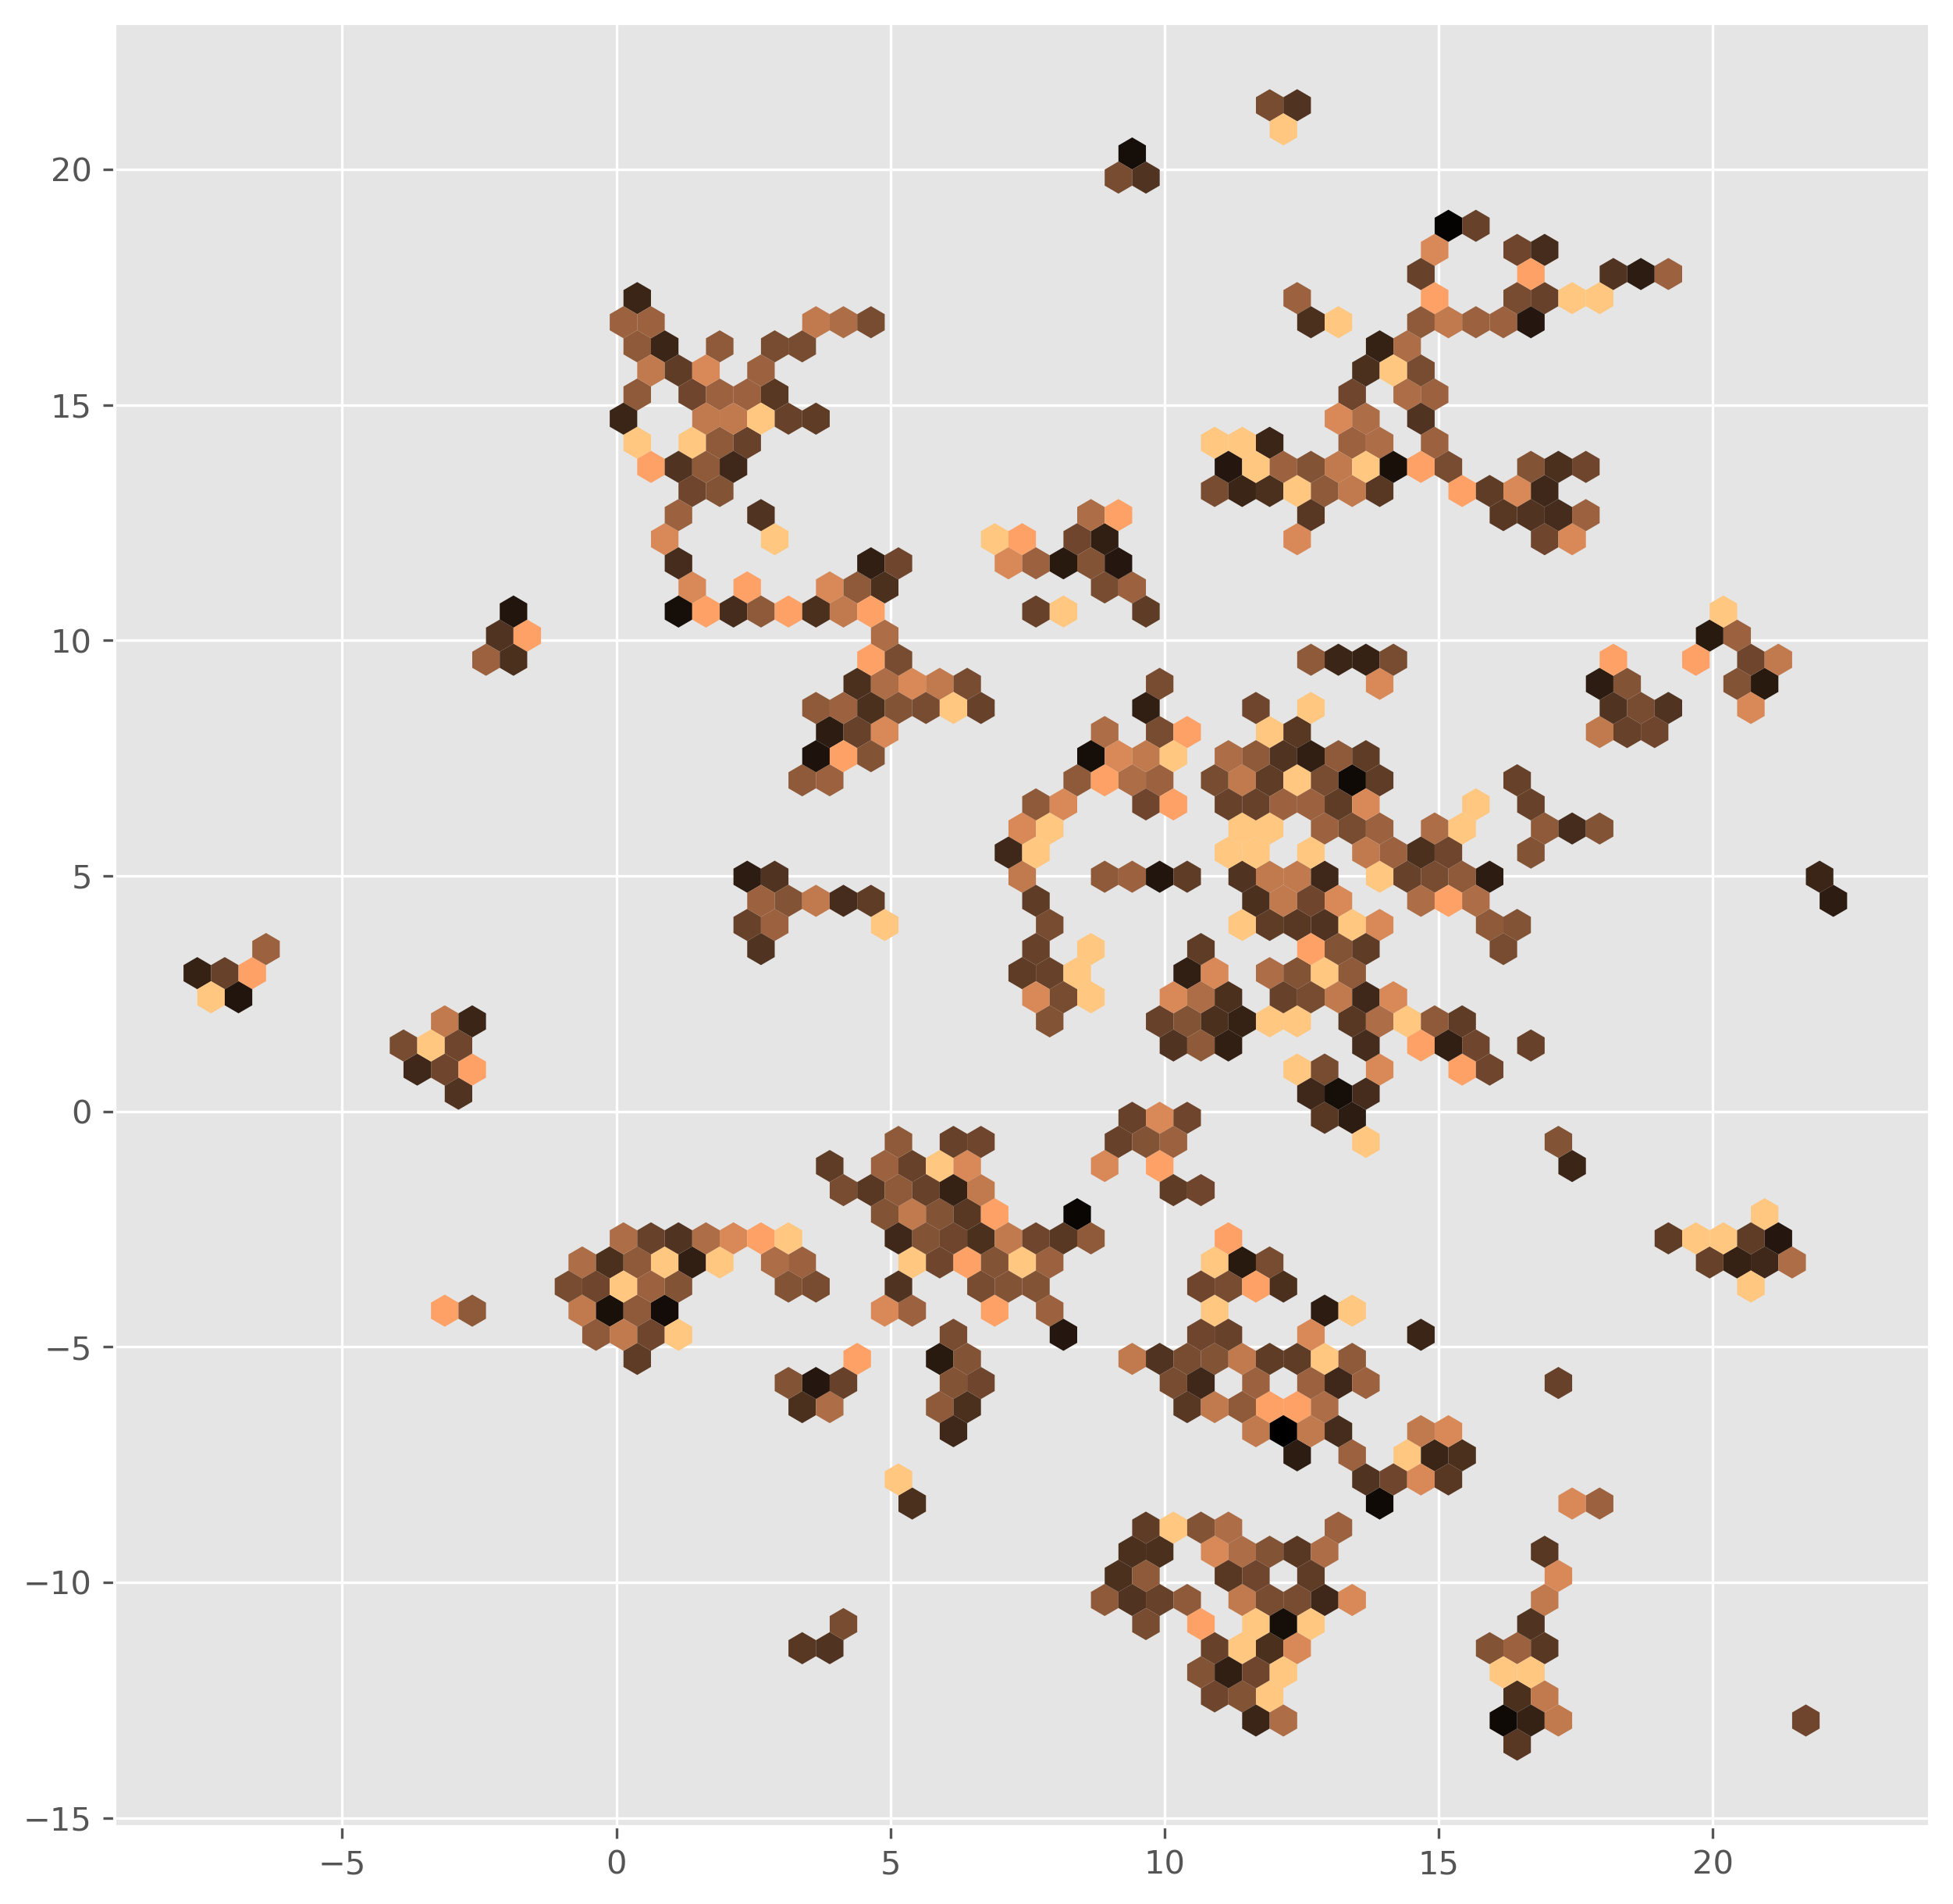

In [21]:
import ast
import glob
import os
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import imageio.v2 as imageio

CSV_PATH = 'active_learning/com/hse_df_feat/al_history_com_rnd_dG_hse_df_feat.csv'
FRAME_DIR = 'temp_al_frames'
GIF_OUTPUT = 'active_learning/com/hse_df_feat/umap_al_com_rnd_dG_hse_df_feat.gif'
TARGET_RUN = 1
FPS = 1.5 # Frames per second for the output GIF

# ── LOAD AND PREPROCESS DATA ──────────────────────────────────────────────────
results_df = pd.read_csv(CSV_PATH)
run_df = results_df[results_df['run'] == TARGET_RUN].sort_values('cycle')

# Parse CSV stringified lists back into Python lists
parsed_cycles = []
for idx, row in run_df.iterrows():
    raw_indices = row['queried_idx']
    if isinstance(raw_indices, str):
        indices_list = ast.literal_eval(raw_indices)
    else:
        indices_list = raw_indices
    parsed_cycles.append((int(row['cycle']), indices_list))

# Initialize a perfect square canvas
fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

# Layer 1: Background Density Map (Log scaled)
hb = ax.hexbin(
    X_umap[:, 0],
    X_umap[:, 1],
    gridsize=60,
    cmap='copper_r',
    mincnt=1,
    edgecolors='none',
    norm=colors.LogNorm()
)
plt.show()

In [34]:
import ast
import glob
import os
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import imageio.v2 as imageio

# ── PARAMETERS & CONFIGURATION ────────────────────────────────────────────────
CSV_PATH = 'active_learning/xgb/hse_df_feat/al_history_xgb_unc_dG_hse_df_feat.csv'
FRAME_DIR = 'temp_al_frames'
GIF_OUTPUT = 'active_learning/xgb/hse_df_feat/umap_al_xgb_unc_dG_hse_df_feat.gif'
TARGET_RUN = 1
FPS = 1.5 # Frames per second for the output GIF

# ── LOAD AND PREPROCESS DATA ──────────────────────────────────────────────────
results_df = pd.read_csv(CSV_PATH)
run_df = results_df[results_df['run'] == TARGET_RUN].sort_values('cycle')

# Parse CSV stringified lists back into Python lists
parsed_cycles = []
for idx, row in run_df.iterrows():
    raw_indices = row['queried_idx']
    if isinstance(raw_indices, str):
        indices_list = ast.literal_eval(raw_indices)
    else:
        indices_list = raw_indices
    parsed_cycles.append((int(row['cycle']), indices_list))

# ── MAIN ANIMATION LOOP ───────────────────────────────────────────────────────
frame_files = []

for i, (current_cycle, current_batch) in enumerate(parsed_cycles):
    # Retrieve and separate historically labeled vs. newly queried points
    previous_indices = []
    for cycle_num, indices in parsed_cycles[:i]:
        previous_indices.extend(indices)
    
    total_labeled_count = len(previous_indices) + len(current_batch)

    # Initialize a perfect square canvas
    fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
    
    # Layer 1: Background Density Map (Log scaled)
    hb = ax.hexbin(
        X_umap[:, 0],
        X_umap[:, 1],
        gridsize=60,
        cmap='copper_r',
        mincnt=1,
        edgecolors='none',
        norm=colors.LogNorm()
    )

    # Layer 2: Previously Labeled points (Colored by ground-truth property)
    sc = ax.scatter(
        X_umap[previous_indices, 0],
        X_umap[previous_indices, 1],
        c=y_train[previous_indices],
        cmap='viridis',
        # vmin=0.0,
        # vmax=0.7,
        marker='o',
        edgecolors='none',
        s=10,
        alpha=0.7,
        label='Previously Labeled',
    )

    # Layer 3: Newly Labeled Points (A acquisition target highlighted in pink)
    ax.scatter(
        X_umap[current_batch, 0],
        X_umap[current_batch, 1],
        c='#FF0055',
        marker='o',
        s=4,
        alpha=0.75,
        label='Newly Labeled',
    )

    # Align 1:1 coordinate spans to keep the physical aspect ratio square
    x_min, x_max = X_umap[:, 0].min(), X_umap[:, 0].max()
    y_min, y_max = X_umap[:, 1].min(), X_umap[:, 1].max()
    limit_min = min(x_min, y_min) - 0.5
    limit_max = max(x_max, y_max) + 0.5
    
    ax.set_xlim(limit_min, limit_max)
    ax.set_ylim(limit_min, limit_max)
    ax.set_aspect('equal', adjustable='box')

    # Position colorbars using relative canvas coordinates
    ax_cb_horizontal = ax.inset_axes([0.1, -0.07, 0.8, 0.03])
    cb_density = fig.colorbar(hb, cax=ax_cb_horizontal, orientation='horizontal')
    cb_density.set_label('Molecule Density (Count per Hex)', fontsize=10, fontweight='bold')
    
    ax_cb_vertical = ax.inset_axes([1.03, 0.1, 0.03, 0.8])
    cb_gap = fig.colorbar(sc, cax=ax_cb_vertical)
    cb_gap.set_label('dG (eV)', fontsize=10, fontweight='bold')

    # Titles and Legends
    ax.set_title(
        f'QM9 Chemical Space (UMAP)\n'
        f'Run {TARGET_RUN} | Cycle {current_cycle} | {total_labeled_count} Total Labeled',
        fontsize=13,
        fontweight='bold',
        pad=15
    )
    
    ax.legend(
        loc='upper right', 
        scatterpoints=1, 
        markerscale=1.5, 
        frameon=True, 
        facecolor='white', 
        edgecolor='none',
        fontsize=9
    )

    # plt.show()
    # Save current cycle plot frame
    frame_path = os.path.join(FRAME_DIR, f'frame_{current_cycle:03d}.png')
    plt.savefig(frame_path, dpi=150) # Use 150 DPI for faster writing
    plt.close(fig)
    
    frame_files.append(frame_path)
    print(f'Rendered Frame for Cycle {current_cycle}')

# ── STEP 5: COMPILING INDIVIDUAL FRAMES INTO A GIF ───────────────────────────
print("Compiling global GIF animation...")
images = [imageio.imread(f) for f in frame_files]
imageio.mimsave(GIF_OUTPUT, images, fps=FPS)

# Optional cleanup: Delete temporary PNG frame files
for f in frame_files:
    os.remove(f)

print(f"Success! Saved evolution animation to: '{GIF_OUTPUT}'")

Rendered Frame for Cycle 1
Rendered Frame for Cycle 2
Rendered Frame for Cycle 3
Rendered Frame for Cycle 4
Rendered Frame for Cycle 5
Rendered Frame for Cycle 6
Rendered Frame for Cycle 7
Rendered Frame for Cycle 8
Rendered Frame for Cycle 9
Rendered Frame for Cycle 10
Rendered Frame for Cycle 11
Compiling global GIF animation...
Success! Saved evolution animation to: 'active_learning/xgb/hse_df_feat/umap_al_xgb_unc_dG_hse_df_feat.gif'


### Violins plots

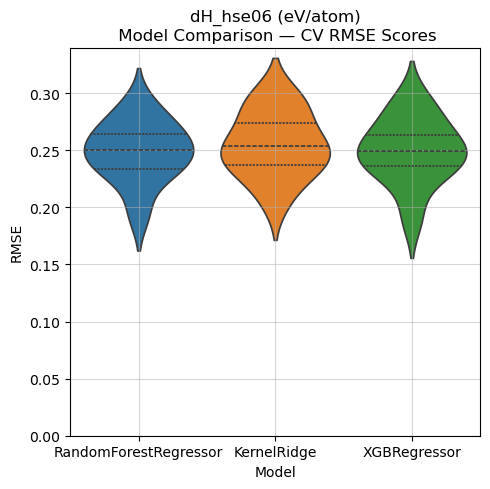

In [34]:
models_1 = [rf_1, kr_1, xgb_1]
make_violin_plot_rmse(X, y1, models_1)

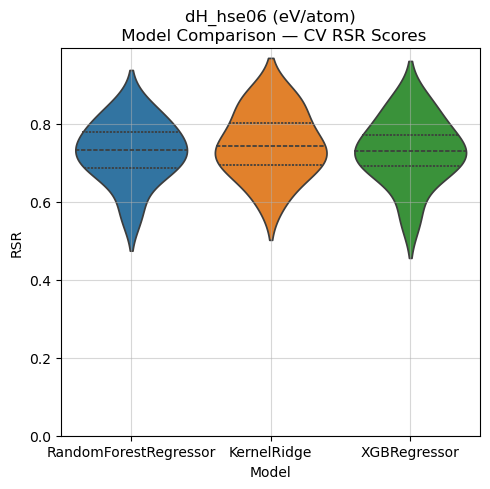

In [35]:
make_violin_plot_rsr(X, y1, models_1)

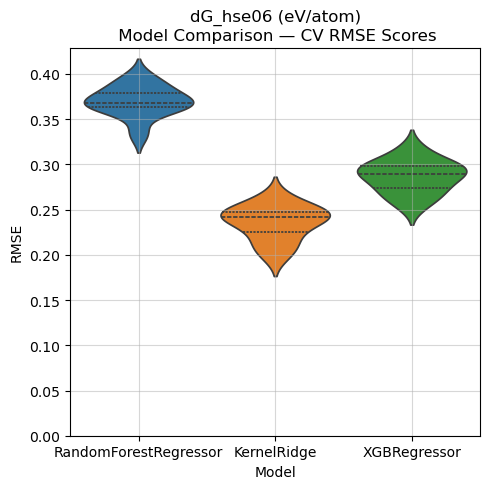

In [36]:
models_2 = [rf_2, kr_2, xgb_2]
make_violin_plot_rmse(X, y2, models_2)

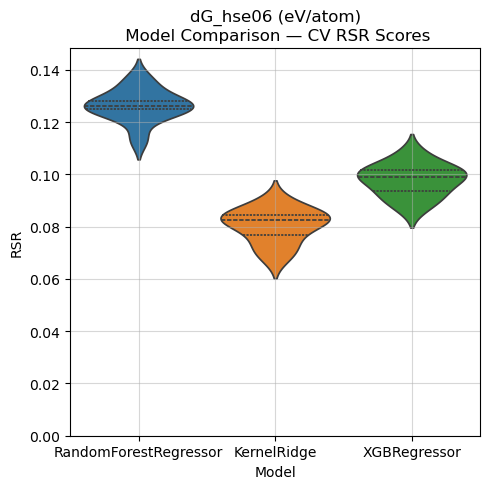

In [37]:
make_violin_plot_rsr(X, y2, models_2)